# Task 2: 2D U-Net for BraTS Multi-modal MRI Segmentation

This notebook trains a baseline 2D U-Net for glioma segmentation using preprocessed BraTS 2D slices.

Input:

```python
image.shape = [4, 192, 208]
Label:

label.shape = [3, 192, 208]
The three label channels are assumed to be:

channel 0: WT, Whole Tumor
channel 1: TC, Tumor Core
channel 2: ET, Enhancing Tumor
Because WT, TC and ET are nested regions, this is treated as a multi-label segmentation task.

Therefore, the model uses:

sigmoid activation
Dice Loss + BCEWithLogitsLoss

1. Imports
This cell imports all required packages.

In [1]:
import os
import csv
import math
import random
import time
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

from task2_attention_unet_utils import (
    AttUNet,
    Attention_block,
    collect_files_for_cases,
    run_test_evaluation,
    split_cases_patient_level,
    write_case_list,
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4060 Laptop GPU


d:\Miniconda\envs\bmeproj2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

This is the main configuration cell.

Modify this cell if you want to change:

- data path
- batch size
- epoch number
- learning rate
- output directory
- data augmentation
- visualization frequency

In [2]:
# ============================================================
# Configuration
# ============================================================

DATA_ROOT = Path("outputs_task1/processed_slices")
if not DATA_ROOT.exists():
    fallback_data_root = Path(r"D:\Imaging\project2\processed_slices")
    if fallback_data_root.exists():
        DATA_ROOT = fallback_data_root

OUTPUT_DIR = Path("outputs_task2_unet2d")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_KEY = "image"
LABEL_KEY = "label"

IN_CHANNELS = 4
OUT_CHANNELS = 3

IMAGE_HEIGHT = 192
IMAGE_WIDTH = 208

REGION_NAMES = ["WT", "TC", "ET"]

SEED = 42
RANDOM_SEED = SEED
TRAIN_RATIO = 0.65
VAL_RATIO = 0.20
TEST_RATIO = 0.15

BATCH_SIZE = 8
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
BASE_CHANNELS = 32
USE_ATTENTION_UNET = False

# For Windows + Jupyter, NUM_WORKERS = 0 is the safest option.
NUM_WORKERS = 0

USE_AUGMENTATION = True
USE_AMP = True

THRESHOLD = 0.5
VIS_EVERY_N_EPOCHS = 5
EARLY_STOPPING_PATIENCE = 20

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DATA_ROOT:", DATA_ROOT.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("DEVICE:", DEVICE)
print("Model type:", "Attention U-Net" if USE_ATTENTION_UNET else "Baseline U-Net")

DATA_ROOT: D:\Classes\AIformedical\LAB2\Lab2\outputs_task1\processed_slices
OUTPUT_DIR: D:\Classes\AIformedical\LAB2\Lab2\outputs_task2_unet2d
DEVICE: cuda
Model type: Baseline U-Net


## 3. Reproducibility

This cell fixes random seeds for Python, NumPy and PyTorch.

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


set_seed(RANDOM_SEED)

## 4. Scan Dataset and Patient-level Split

This cell scans all `.npz` files under `processed_slices`.

The split is performed at patient level, not slice level.

This avoids data leakage because slices from the same patient should not appear in both training and validation sets.

In [4]:
def scan_dataset(data_root):
    data_root = Path(data_root)

    if not data_root.exists():
        raise FileNotFoundError(f"DATA_ROOT does not exist: {data_root}")

    all_npz_files = sorted(data_root.glob("*/*.npz"))
    case_to_files = defaultdict(list)

    for path in all_npz_files:
        case_id = path.parent.name
        case_to_files[case_id].append(path)

    case_ids = sorted(case_to_files.keys())

    print("Number of cases:", len(case_ids))
    print("Number of slices:", len(all_npz_files))

    counts = [len(case_to_files[c]) for c in case_ids]
    print("Slices per case:")
    print("  min   :", min(counts))
    print("  max   :", max(counts))
    print("  mean  :", float(np.mean(counts)))
    print("  median:", float(np.median(counts)))

    return case_to_files, case_ids


case_to_files, case_ids = scan_dataset(DATA_ROOT)

train_cases, val_cases, test_cases = split_cases_patient_level(
    case_ids=case_ids,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=SEED,
)

train_files = collect_files_for_cases(case_to_files, train_cases)
val_files = collect_files_for_cases(case_to_files, val_cases)
test_files = collect_files_for_cases(case_to_files, test_cases)

print()
print(
    f"Target split ratios: train={TRAIN_RATIO:.2f}, "
    f"val={VAL_RATIO:.2f}, test={TEST_RATIO:.2f}"
)
print("Random seed:", SEED)
print("Train cases:", len(train_cases))
print("Val cases  :", len(val_cases))
print("Test cases :", len(test_cases))
print("Train slices:", len(train_files))
print("Val slices  :", len(val_files))
print("Test slices :", len(test_files))
print(
    "Actual case split:",
    f"{len(train_cases) / len(case_ids):.3f}/",
    f"{len(val_cases) / len(case_ids):.3f}/",
    f"{len(test_cases) / len(case_ids):.3f}",
)

write_case_list(OUTPUT_DIR / "train_cases.txt", train_cases)
write_case_list(OUTPUT_DIR / "val_cases.txt", val_cases)
write_case_list(OUTPUT_DIR / "test_cases.txt", test_cases)

Number of cases: 595
Number of slices: 38976
Slices per case:
  min   : 25
  max   : 109
  mean  : 65.50588235294117
  median: 66.0

Target split ratios: train=0.65, val=0.20, test=0.15
Random seed: 42
Train cases: 387
Val cases  : 119
Test cases : 89
Train slices: 25332
Val slices  : 7882
Test slices : 5762
Actual case split: 0.650/ 0.200/ 0.150


## 5. Quick Data Sanity Check

This cell reads one `.npz` sample and checks:

- keys
- image shape
- label shape
- label values
- case ID
- slice index
- modality order
- label order

In [5]:
def read_npz_value(x):
    if isinstance(x, np.ndarray):
        if x.shape == ():
            return x.item()
        return x.tolist()

    return x


def inspect_npz(path):
    with np.load(path, allow_pickle=True) as data:
        print("File:", path)
        print("Keys:", list(data.files))

        image = data[IMAGE_KEY]
        label = data[LABEL_KEY]

        print("image shape:", image.shape, image.dtype)
        print("label shape:", label.shape, label.dtype)
        print("label unique:", np.unique(label))

        if "case_id" in data:
            print("case_id:", read_npz_value(data["case_id"]))

        if "slice_idx" in data:
            print("slice_idx:", read_npz_value(data["slice_idx"]))

        if "modality_order" in data:
            print("modality_order:", read_npz_value(data["modality_order"]))

        if "label_order" in data:
            print("label_order:", read_npz_value(data["label_order"]))


inspect_npz(train_files[0])

File: outputs_task1\processed_slices\BraTS-GLI-00000-000\BraTS-GLI-00000-000_slice_045.npz
Keys: ['image', 'label', 'case_id', 'slice_idx', 'original_shape', 'cropped_shape', 'padded_shape', 'target_h', 'target_w', 'image_padding_values', 'modality_order', 'label_order']
image shape: (4, 192, 208) float32
label shape: (3, 192, 208) uint8
label unique: [0 1]
case_id: BraTS-GLI-00000-000
slice_idx: 45
modality_order: ['T1', 'T1ce', 'T2', 'FLAIR']
label_order: ['WT', 'TC', 'ET']


## 6. Core Component: Dataset and Data Augmentation

This is one of the core cells.

The dataset returns:

```python
image: [4, 192, 208]
label: [3, 192, 208]
Data augmentation includes:

random horizontal flip
random vertical flip
random affine transformation
Gaussian noise
Important:

image uses bilinear interpolation
label uses nearest-neighbor interpolation
label remains binary after augmentation

In [6]:
def random_affine_torch(image, label, max_angle=10.0, scale_range=(0.9, 1.1), p=0.5):
    if random.random() > p:
        return image, label

    angle = random.uniform(-max_angle, max_angle) * math.pi / 180.0
    scale = random.uniform(scale_range[0], scale_range[1])

    cos_a = math.cos(angle) / scale
    sin_a = math.sin(angle) / scale

    theta = torch.tensor(
        [
            [cos_a, -sin_a, 0.0],
            [sin_a, cos_a, 0.0],
        ],
        dtype=image.dtype,
        device=image.device,
    )

    theta = theta.unsqueeze(0)

    image_4d = image.unsqueeze(0)
    label_4d = label.unsqueeze(0)

    grid = F.affine_grid(
        theta,
        image_4d.size(),
        align_corners=False,
    )

    image_aug = F.grid_sample(
        image_4d,
        grid,
        mode="bilinear",
        padding_mode="zeros",
        align_corners=False,
    )

    label_aug = F.grid_sample(
        label_4d,
        grid,
        mode="nearest",
        padding_mode="zeros",
        align_corners=False,
    )

    image_aug = image_aug.squeeze(0)
    label_aug = label_aug.squeeze(0)

    label_aug = (label_aug > 0.5).float()

    return image_aug, label_aug


def apply_augmentation(image, label):
    if random.random() < 0.5:
        image = torch.flip(image, dims=[2])
        label = torch.flip(label, dims=[2])

    if random.random() < 0.5:
        image = torch.flip(image, dims=[1])
        label = torch.flip(label, dims=[1])

    image, label = random_affine_torch(
        image,
        label,
        max_angle=10.0,
        scale_range=(0.9, 1.1),
        p=0.5,
    )

    if random.random() < 0.3:
        noise_std = random.uniform(0.0, 0.05)
        image = image + noise_std * torch.randn_like(image)

    return image, label


class BraTSSliceDataset(Dataset):
    def __init__(self, files, augment=False):
        self.files = list(files)
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]

        with np.load(path, allow_pickle=True) as data:
            image = data[IMAGE_KEY].astype(np.float32)
            label = data[LABEL_KEY].astype(np.float32)

            if "case_id" in data:
                case_id = read_npz_value(data["case_id"])
            else:
                case_id = path.parent.name

            if "slice_idx" in data:
                slice_idx = int(read_npz_value(data["slice_idx"]))
            else:
                slice_idx = -1

        expected_image_shape = (IN_CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH)
        expected_label_shape = (OUT_CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH)

        if image.shape != expected_image_shape:
            raise ValueError(f"Unexpected image shape {image.shape} in {path}")

        if label.shape != expected_label_shape:
            raise ValueError(f"Unexpected label shape {label.shape} in {path}")

        image = torch.from_numpy(image).float()
        label = torch.from_numpy(label).float()

        if self.augment:
            image, label = apply_augmentation(image, label)

        sample = {
            "image": image,
            "label": label,
            "case_id": str(case_id),
            "slice_idx": int(slice_idx),
            "path": str(path),
        }

        return sample


train_dataset = BraTSSliceDataset(train_files, augment=USE_AUGMENTATION)
val_dataset = BraTSSliceDataset(val_files, augment=False)
test_dataset = BraTSSliceDataset(test_files, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

batch = next(iter(train_loader))

print("Batch image:", batch["image"].shape, batch["image"].dtype)
print("Batch label:", batch["label"].shape, batch["label"].dtype)
print("Example case_id:", batch["case_id"][0])
print("Example slice_idx:", batch["slice_idx"][0])
print("Dataset sizes:", len(train_dataset), len(val_dataset), len(test_dataset))
print("Loader batches:", len(train_loader), len(val_loader), len(test_loader))

Batch image: torch.Size([8, 4, 192, 208]) torch.float32
Batch label: torch.Size([8, 3, 192, 208]) torch.float32
Example case_id: BraTS-GLI-00049-000
Example slice_idx: tensor(71)
Dataset sizes: 25332 7882 5762
Loader batches: 3167 986 721


## 7. Visualize Training Sample

This cell visualizes one image slice and its WT / TC / ET masks.

If modality order is `[T1, T1ce, T2, FLAIR]`, then channel 3 is FLAIR.

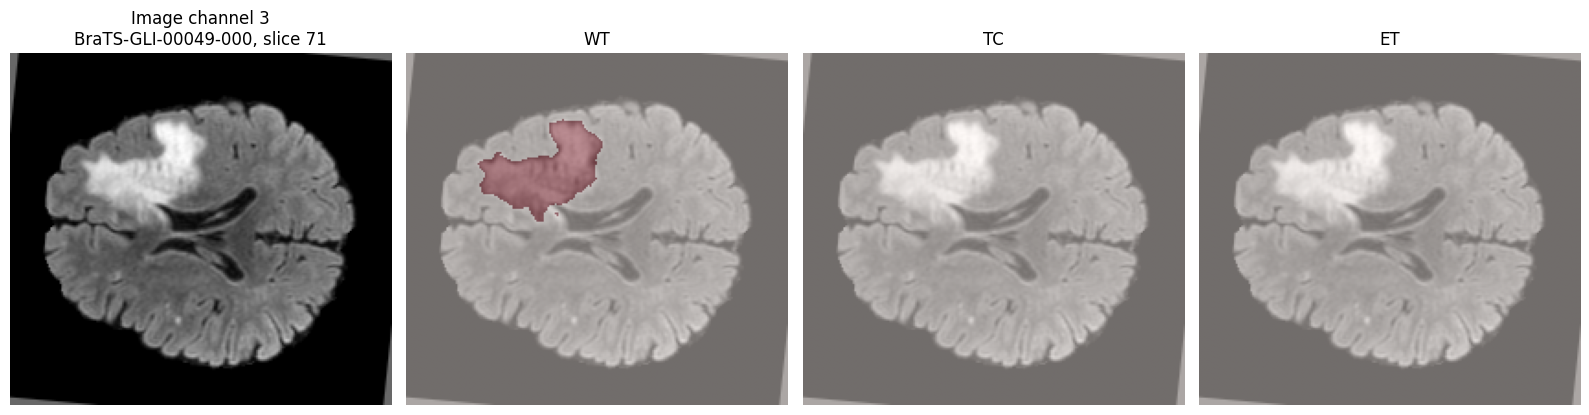

In [7]:
def show_sample_from_batch(batch, index=0, image_channel=3):
    image = batch["image"][index].numpy()
    label = batch["label"][index].numpy()

    case_id = batch["case_id"][index]
    slice_idx = batch["slice_idx"][index]

    if torch.is_tensor(slice_idx):
        slice_idx = slice_idx.item()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(image[image_channel], cmap="gray")
    axes[0].set_title(f"Image channel {image_channel}\n{case_id}, slice {slice_idx}")
    axes[0].axis("off")

    for i, name in enumerate(REGION_NAMES):
        axes[i + 1].imshow(image[image_channel], cmap="gray")
        axes[i + 1].imshow(label[i], cmap="Reds", alpha=0.45)
        axes[i + 1].set_title(name)
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()


show_sample_from_batch(batch, index=0, image_channel=3)

## 8. Core Component: U-Net Network Architecture

This is the main model definition cell.

Input:

```python
[B, 4, 192, 208]
Output logits:

[B, 3, 192, 208]
The final layer does not use sigmoid.

Sigmoid is applied inside the loss function and during validation.

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.Upsample(
            scale_factor=2,
            mode="bilinear",
            align_corners=True,
        )

        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)

        x1 = F.pad(
            x1,
            [
                diff_x // 2,
                diff_x - diff_x // 2,
                diff_y // 2,
                diff_y - diff_y // 2,
            ],
        )

        x = torch.cat([x2, x1], dim=1)

        return self.conv(x)


class UNet2D(nn.Module):
    def __init__(self, in_channels=4, out_channels=3, base_channels=32):
        super().__init__()

        self.in_conv = DoubleConv(in_channels, base_channels)

        self.down1 = Down(base_channels, base_channels * 2)
        self.down2 = Down(base_channels * 2, base_channels * 4)
        self.down3 = Down(base_channels * 4, base_channels * 8)
        self.down4 = Down(base_channels * 8, base_channels * 16)

        self.up1 = Up(base_channels * 16 + base_channels * 8, base_channels * 8)
        self.up2 = Up(base_channels * 8 + base_channels * 4, base_channels * 4)
        self.up3 = Up(base_channels * 4 + base_channels * 2, base_channels * 2)
        self.up4 = Up(base_channels * 2 + base_channels, base_channels)

        self.out_conv = nn.Conv2d(
            base_channels,
            out_channels,
            kernel_size=1,
        )

    def forward(self, x):
        x1 = self.in_conv(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.out_conv(x)

        return logits


model_class = AttUNet if USE_ATTENTION_UNET else UNet2D
model = model_class(
    in_channels=IN_CHANNELS,
    out_channels=OUT_CHANNELS,
    base_channels=BASE_CHANNELS,
).to(DEVICE)

x_test = torch.randn(
    1,
    IN_CHANNELS,
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
).to(DEVICE)

with torch.no_grad():
    y_test = model(x_test)

print("Model class:", model.__class__.__name__)
print("Input shape:", x_test.shape)
print("Output shape:", y_test.shape)

expected_shape = (1, OUT_CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH)
assert (
    tuple(y_test.shape) == expected_shape
), f"Expected output shape {expected_shape}, got {tuple(y_test.shape)}"

num_params = sum(p.numel() for p in model.parameters())
num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {num_params:,}")
print(f"Trainable parameters: {num_trainable:,}")

Model class: UNet2D
Input shape: torch.Size([1, 4, 192, 208])
Output shape: torch.Size([1, 3, 192, 208])
Total parameters: 7,849,955
Trainable parameters: 7,849,955


## 9. Core Component: Dice Loss and Hybrid Loss

This cell defines the loss function.

The final loss is:

```python
Loss = DiceLoss + BCEWithLogitsLoss
This is suitable for class-imbalanced multi-label medical image segmentation.

The model outputs logits, not probabilities.

In [9]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()

        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        dims = (0, 2, 3)

        intersection = torch.sum(probs * targets, dim=dims)
        denominator = torch.sum(probs, dim=dims) + torch.sum(targets, dim=dims)

        dice = (2.0 * intersection + self.smooth) / (
            denominator + self.smooth
        )

        loss = 1.0 - dice

        return loss.mean()


class DiceBCELoss(nn.Module):
    def __init__(self, dice_weight=1.0, bce_weight=1.0):
        super().__init__()

        self.dice_weight = dice_weight
        self.bce_weight = bce_weight

        self.dice_loss = DiceLoss()
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        dice = self.dice_loss(logits, targets)
        bce = self.bce_loss(logits, targets)

        total = self.dice_weight * dice + self.bce_weight * bce

        loss_parts = {
            "dice_loss": float(dice.detach().cpu()),
            "bce_loss": float(bce.detach().cpu()),
        }

        return total, loss_parts


criterion = DiceBCELoss(
    dice_weight=1.0,
    bce_weight=1.0,
).to(DEVICE)

print(criterion)

DiceBCELoss(
  (dice_loss): DiceLoss()
  (bce_loss): BCEWithLogitsLoss()
)


## 10. Core Component: Dice Metric

This cell computes validation Dice for:

- WT
- TC
- ET
- Mean Dice

Prediction is obtained by:

```python
prob = sigmoid(logits)
pred = prob > threshold

In [10]:
class DiceAccumulator:
    def __init__(self, num_channels=3, threshold=0.5, smooth=1e-5):
        self.num_channels = num_channels
        self.threshold = threshold
        self.smooth = smooth

        self.intersection = torch.zeros(num_channels, dtype=torch.float64)
        self.pred_sum = torch.zeros(num_channels, dtype=torch.float64)
        self.target_sum = torch.zeros(num_channels, dtype=torch.float64)

    @torch.no_grad()
    def update(self, logits, targets):
        probs = torch.sigmoid(logits)
        preds = (probs > self.threshold).float()
        targets = targets.float()

        dims = (0, 2, 3)

        intersection = torch.sum(preds * targets, dim=dims)
        pred_sum = torch.sum(preds, dim=dims)
        target_sum = torch.sum(targets, dim=dims)

        self.intersection += intersection.detach().cpu().double()
        self.pred_sum += pred_sum.detach().cpu().double()
        self.target_sum += target_sum.detach().cpu().double()

    def compute(self):
        dice = (2.0 * self.intersection + self.smooth) / (
            self.pred_sum + self.target_sum + self.smooth
        )

        return dice.numpy()

## 11. Optimizer and Scheduler

This cell defines:

- AdamW optimizer
- ReduceLROnPlateau scheduler
- AMP GradScaler

In [11]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
)

scaler = torch.cuda.amp.GradScaler(
    enabled=(USE_AMP and DEVICE.type == "cuda")
)


def get_current_lr(optimizer):
    return optimizer.param_groups[0]["lr"]


print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


C:\Users\zzj\AppData\Local\Temp\ipykernel_18844\673542364.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(


## 12. Core Component: Training and Validation Loops

This cell defines:

- `train_one_epoch`
- `validate_one_epoch`

This is the main training logic.

In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()

    running_loss = 0.0
    running_dice_loss = 0.0
    running_bce_loss = 0.0
    num_samples = 0

    pbar = tqdm(loader, desc="Train", leave=False)

    for batch in pbar:
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        batch_size = images.size(0)

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None and scaler.is_enabled():
            with torch.cuda.amp.autocast():
                logits = model(images)
                loss, loss_parts = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        else:
            logits = model(images)
            loss, loss_parts = criterion(logits, labels)

            loss.backward()
            optimizer.step()

        running_loss += loss.item() * batch_size
        running_dice_loss += loss_parts["dice_loss"] * batch_size
        running_bce_loss += loss_parts["bce_loss"] * batch_size
        num_samples += batch_size

        pbar.set_postfix(
            {
                "loss": running_loss / max(num_samples, 1),
                "lr": get_current_lr(optimizer),
            }
        )

    metrics = {
        "loss": running_loss / num_samples,
        "dice_loss": running_dice_loss / num_samples,
        "bce_loss": running_bce_loss / num_samples,
    }

    return metrics


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, threshold=0.5):
    model.eval()

    running_loss = 0.0
    running_dice_loss = 0.0
    running_bce_loss = 0.0
    num_samples = 0

    dice_acc = DiceAccumulator(
        num_channels=OUT_CHANNELS,
        threshold=threshold,
    )

    pbar = tqdm(loader, desc="Val", leave=False)

    for batch in pbar:
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        batch_size = images.size(0)

        logits = model(images)
        loss, loss_parts = criterion(logits, labels)

        running_loss += loss.item() * batch_size
        running_dice_loss += loss_parts["dice_loss"] * batch_size
        running_bce_loss += loss_parts["bce_loss"] * batch_size
        num_samples += batch_size

        dice_acc.update(logits, labels)

        pbar.set_postfix(
            {
                "loss": running_loss / max(num_samples, 1),
            }
        )

    dice_values = dice_acc.compute()

    metrics = {
        "loss": running_loss / num_samples,
        "dice_loss": running_dice_loss / num_samples,
        "bce_loss": running_bce_loss / num_samples,
        "dice_wt": float(dice_values[0]),
        "dice_tc": float(dice_values[1]),
        "dice_et": float(dice_values[2]),
        "mean_dice": float(np.mean(dice_values)),
    }

    return metrics

## 13. Prediction Visualization Function

This cell defines the visualization function.

The output image contains:

- input MRI channel
- ground truth WT / TC / ET
- predicted WT / TC / ET

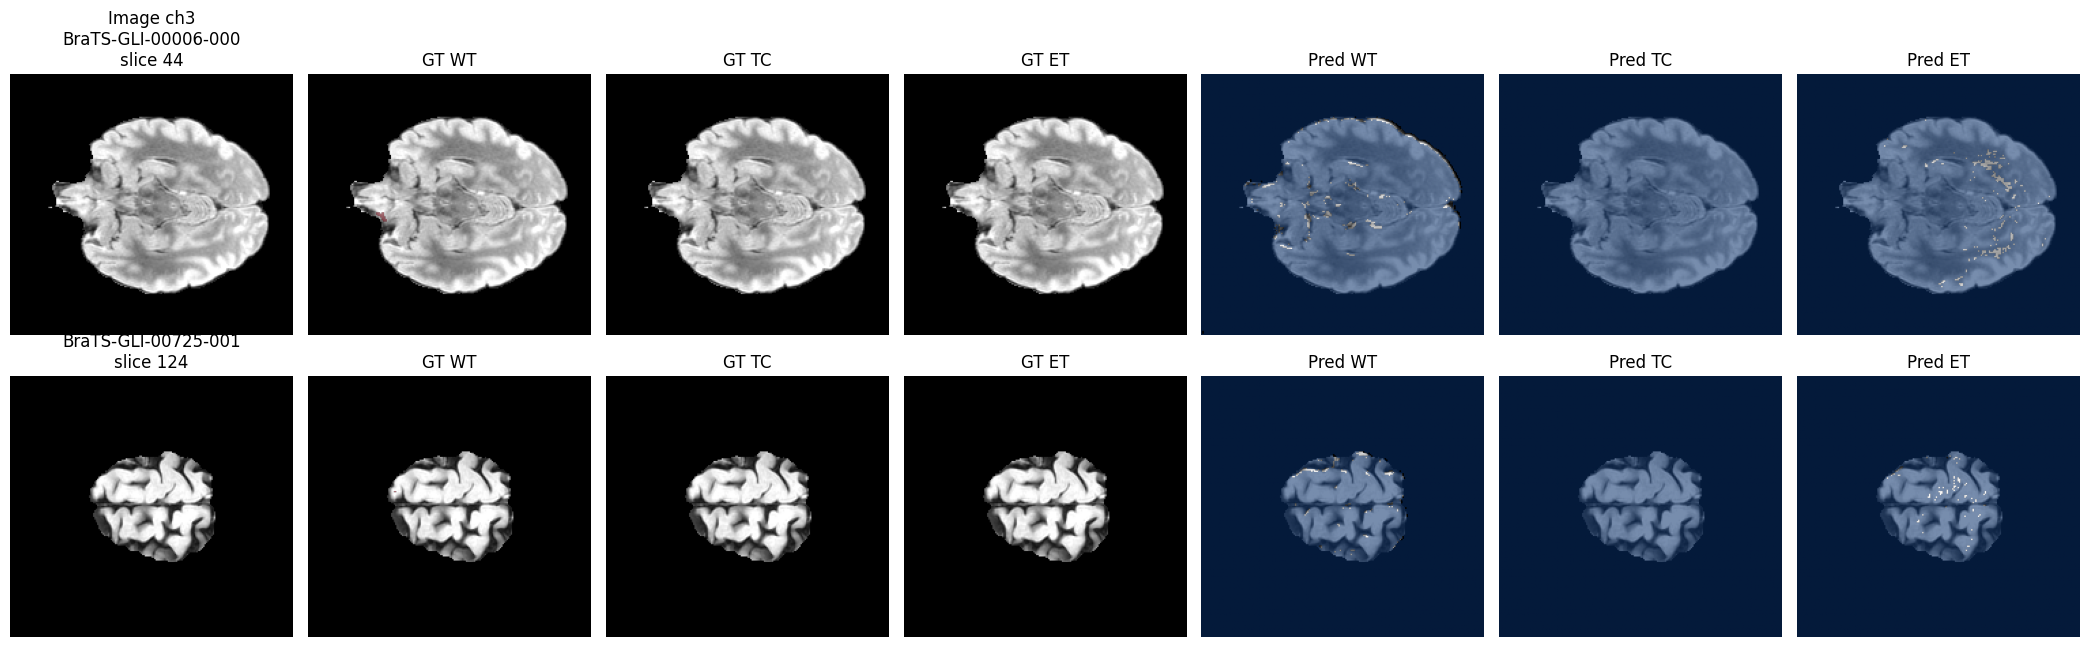

In [13]:
def normalize_mri_for_display(img, eps=1e-6):
    """
    Normalize MRI slice for visualization.

    Purpose:
    - Keep zero-valued background black.
    - Normalize only non-background pixels.
    - Use percentile clipping to improve contrast.

    Input:
        img: 2D numpy array

    Output:
        out: 2D numpy array in [0, 1]
    """
    img = img.astype(np.float32)

    # Treat values very close to zero as background.
    foreground_mask = np.abs(img) > eps

    out = np.zeros_like(img, dtype=np.float32)

    if foreground_mask.sum() == 0:
        return out

    foreground_values = img[foreground_mask]

    vmin = np.percentile(foreground_values, 1)
    vmax = np.percentile(foreground_values, 99)

    if vmax <= vmin:
        return out

    out[foreground_mask] = (img[foreground_mask] - vmin) / (vmax - vmin)
    out = np.clip(out, 0.0, 1.0)

    return out


@torch.no_grad()
def visualize_predictions(
    model,
    dataset,
    device,
    save_path,
    num_samples=3,
    image_channel=3,
    threshold=0.5,
):
    model.eval()

    indices = np.linspace(0, len(dataset) - 1, num_samples).astype(int)

    fig, axes = plt.subplots(
        num_samples,
        7,
        figsize=(21, 3.2 * num_samples),
    )

    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(indices):
        sample = dataset[idx]

        image_tensor = sample["image"].unsqueeze(0).to(device)
        label = sample["label"].numpy()

        logits = model(image_tensor)
        prob = torch.sigmoid(logits)[0].detach().cpu().numpy()
        pred = (prob > threshold).astype(np.float32)

        image_np = sample["image"].numpy()
        bg = image_np[image_channel]

        # Normalize MRI for visualization and force background to black.
        bg_display = normalize_mri_for_display(bg)

        case_id = sample["case_id"]
        slice_idx = sample["slice_idx"]

        # ----------------------------------------------------
        # Column 0: MRI image
        # ----------------------------------------------------
        axes[row, 0].imshow(
            bg_display,
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[row, 0].set_title(
            f"Image ch{image_channel}\n{case_id}\nslice {slice_idx}"
        )
        axes[row, 0].axis("off")

        # ----------------------------------------------------
        # Columns 1-3: GT masks overlay on MRI
        # ----------------------------------------------------
        for c, name in enumerate(REGION_NAMES):
            axes[row, 1 + c].imshow(
                bg_display,
                cmap="gray",
                vmin=0,
                vmax=1,
            )

            gt_mask = np.ma.masked_where(label[c] <= 0.5, label[c])

            axes[row, 1 + c].imshow(
                gt_mask,
                cmap="Reds",
                alpha=0.55,
                vmin=0,
                vmax=1,
            )

            axes[row, 1 + c].set_title(f"GT {name}")
            axes[row, 1 + c].axis("off")

        # ----------------------------------------------------
        # Columns 4-6: Prediction masks overlay on MRI
        # ----------------------------------------------------
        for c, name in enumerate(REGION_NAMES):
            axes[row, 4 + c].imshow(
                bg_display,
                cmap="gray",
                vmin=0,
                vmax=1,
            )

            pred_mask = np.ma.masked_where(pred[c] <= 0.5, pred[c])

            axes[row, 4 + c].imshow(
                pred_mask,
                cmap="Blues",
                alpha=0.55,
                vmin=0,
                vmax=1,
            )

            axes[row, 4 + c].set_title(f"Pred {name}")
            axes[row, 4 + c].axis("off")

    plt.tight_layout()

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


visualize_predictions(
    model=model,
    dataset=val_dataset,
    device=DEVICE,
    save_path=OUTPUT_DIR / "prediction_before_training_black_bg_overlay.png",
    num_samples=2,
    image_channel=3,
    threshold=THRESHOLD,
)

## 14. Main Training Loop

This cell starts training.

It saves:

```text
outputs_task2_unet2d/
├── best_model.pth
├── last_model.pth
├── logs.csv
├── prediction_before_training.png
├── prediction_epoch_xxx.png
The best model is selected by validation mean Dice.

Starting training from scratch.
Epoch 1/80


Train:   0%|          | 0/3167 [00:00<?, ?it/s]C:\Users\zzj\AppData\Local\Temp\ipykernel_11244\331614103.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


LR: 1.000000e-03 | Train Loss: 0.2450 | Val Loss: 0.3997 | Dice WT: 0.8935 | Dice TC: 0.8544 | Dice ET: 0.8696 | Mean Dice: 0.8725
Early stopping counter: 0/20
Saved new best model. Mean Dice = 0.8725
Epoch 2/80


LR: 1.000000e-03 | Train Loss: 0.1237 | Val Loss: 0.3536 | Dice WT: 0.9223 | Dice TC: 0.8925 | Dice ET: 0.8819 | Mean Dice: 0.8989
Early stopping counter: 0/20
Saved new best model. Mean Dice = 0.8989
Epoch 3/80


LR: 1.000000e-03 | Train Loss: 0.1121 | Val Loss: 0.3354 | Dice WT: 0.9313 | Dice TC: 0.8953 | Dice ET: 0.9009 | Mean Dice: 0.9091
Early stopping counter: 0/20
Saved new best model. Mean Dice = 0.9091
Epoch 4/80


LR: 1.000000e-03 | Train Loss: 0.1048 | Val Loss: 0.3283 | Dice WT: 0.9352 | Dice TC: 0.8993 | Dice ET: 0.9014 | Mean Dice: 0.9120
Early stopping counter: 0/20
Saved new best model. Mean Dice = 0.9120
Epoch 5/80


LR: 1.000000e-03 | Train Loss: 0.0997 | Val Loss: 0.3375 | Dice WT: 0.9363 | Dice TC: 0.8998 | Dice ET: 0.9027 | Mean Dice: 0.9129
Early stopping counter: 0/20
Saved new best model. Mean Dice = 0.9129


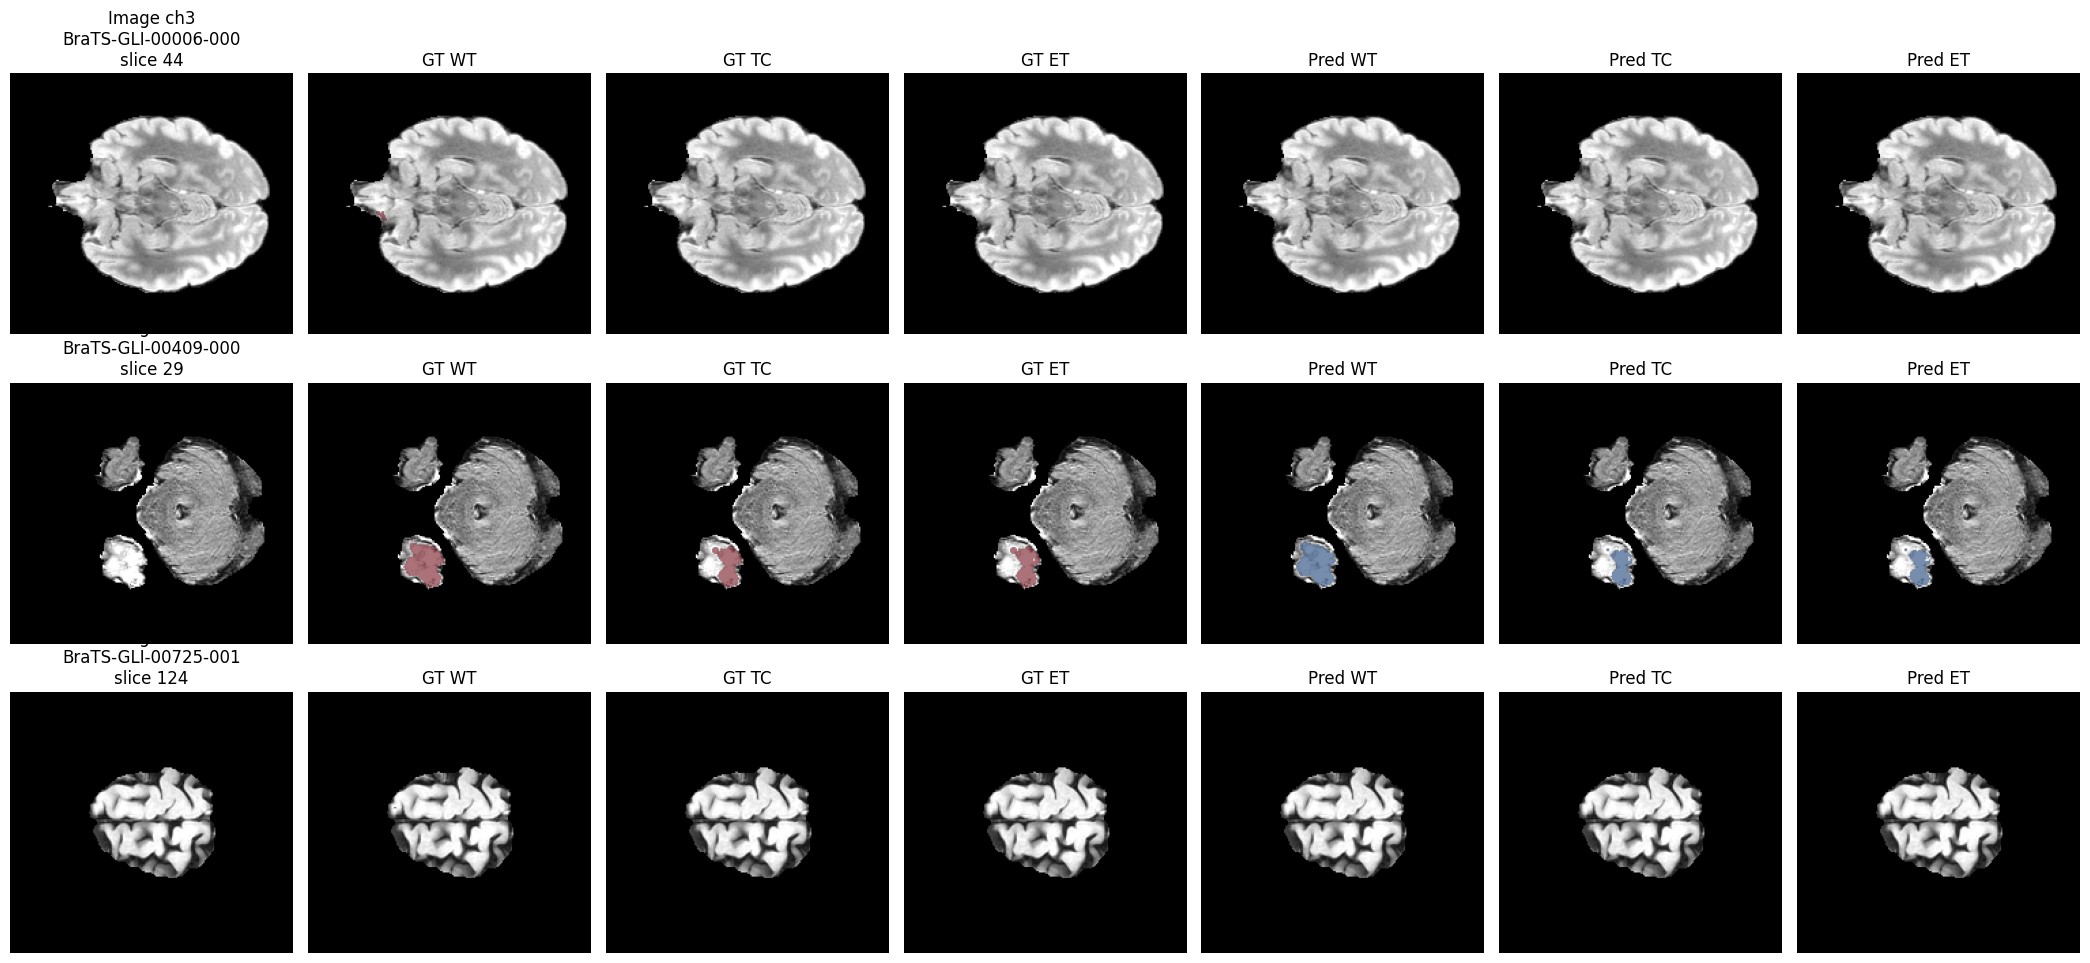

Epoch 6/80


LR: 1.000000e-03 | Train Loss: 0.0958 | Val Loss: 0.3647 | Dice WT: 0.9253 | Dice TC: 0.8734 | Dice ET: 0.8672 | Mean Dice: 0.8886
Early stopping counter: 1/20
Epoch 7/80


LR: 1.000000e-03 | Train Loss: 0.0926 | Val Loss: 0.3403 | Dice WT: 0.9306 | Dice TC: 0.8937 | Dice ET: 0.8981 | Mean Dice: 0.9075
Early stopping counter: 2/20
Epoch 8/80


LR: 1.000000e-03 | Train Loss: 0.0916 | Val Loss: 0.3223 | Dice WT: 0.9380 | Dice TC: 0.8993 | Dice ET: 0.9039 | Mean Dice: 0.9137
Early stopping counter: 0/20
Saved new best model. Mean Dice = 0.9137
Epoch 9/80


LR: 1.000000e-03 | Train Loss: 0.0887 | Val Loss: 0.3191 | Dice WT: 0.9396 | Dice TC: 0.9096 | Dice ET: 0.9083 | Mean Dice: 0.9192
Early stopping counter: 0/20
Saved new best model. Mean Dice = 0.9192
Epoch 10/80


LR: 1.000000e-03 | Train Loss: 0.0869 | Val Loss: 0.3354 | Dice WT: 0.9324 | Dice TC: 0.8907 | Dice ET: 0.9020 | Mean Dice: 0.9084
Early stopping counter: 1/20


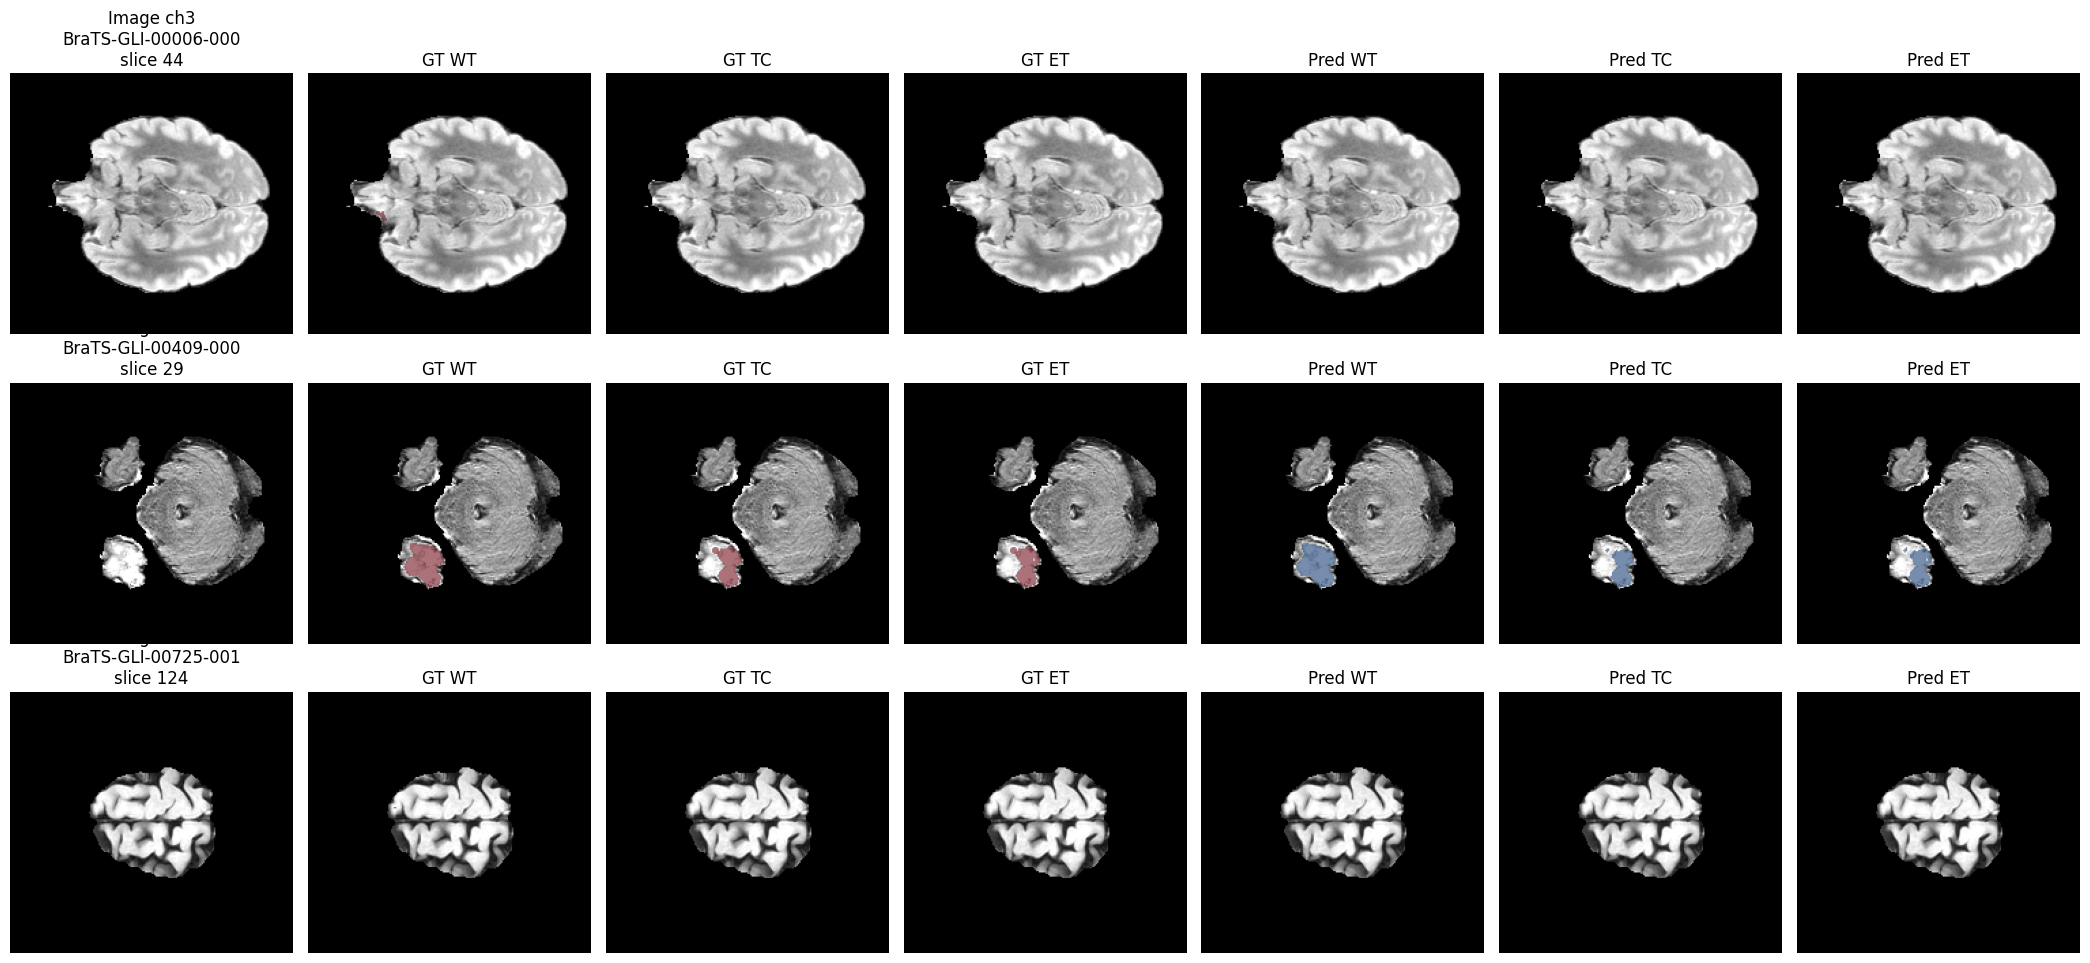

Epoch 11/80


LR: 1.000000e-03 | Train Loss: 0.0856 | Val Loss: 0.3184 | Dice WT: 0.9414 | Dice TC: 0.9052 | Dice ET: 0.9072 | Mean Dice: 0.9179
Early stopping counter: 2/20
Epoch 12/80


LR: 1.000000e-03 | Train Loss: 0.0839 | Val Loss: 0.3200 | Dice WT: 0.9389 | Dice TC: 0.9067 | Dice ET: 0.9087 | Mean Dice: 0.9181
Early stopping counter: 3/20
Epoch 13/80


LR: 1.000000e-03 | Train Loss: 0.0842 | Val Loss: 0.3290 | Dice WT: 0.9365 | Dice TC: 0.8967 | Dice ET: 0.9044 | Mean Dice: 0.9125
Early stopping counter: 4/20
Epoch 14/80


LR: 1.000000e-03 | Train Loss: 0.0813 | Val Loss: 0.3241 | Dice WT: 0.9364 | Dice TC: 0.9044 | Dice ET: 0.9034 | Mean Dice: 0.9147
Early stopping counter: 5/20
Epoch 15/80


LR: 5.000000e-04 | Train Loss: 0.0802 | Val Loss: 0.3230 | Dice WT: 0.9380 | Dice TC: 0.9007 | Dice ET: 0.9063 | Mean Dice: 0.9150
Early stopping counter: 6/20


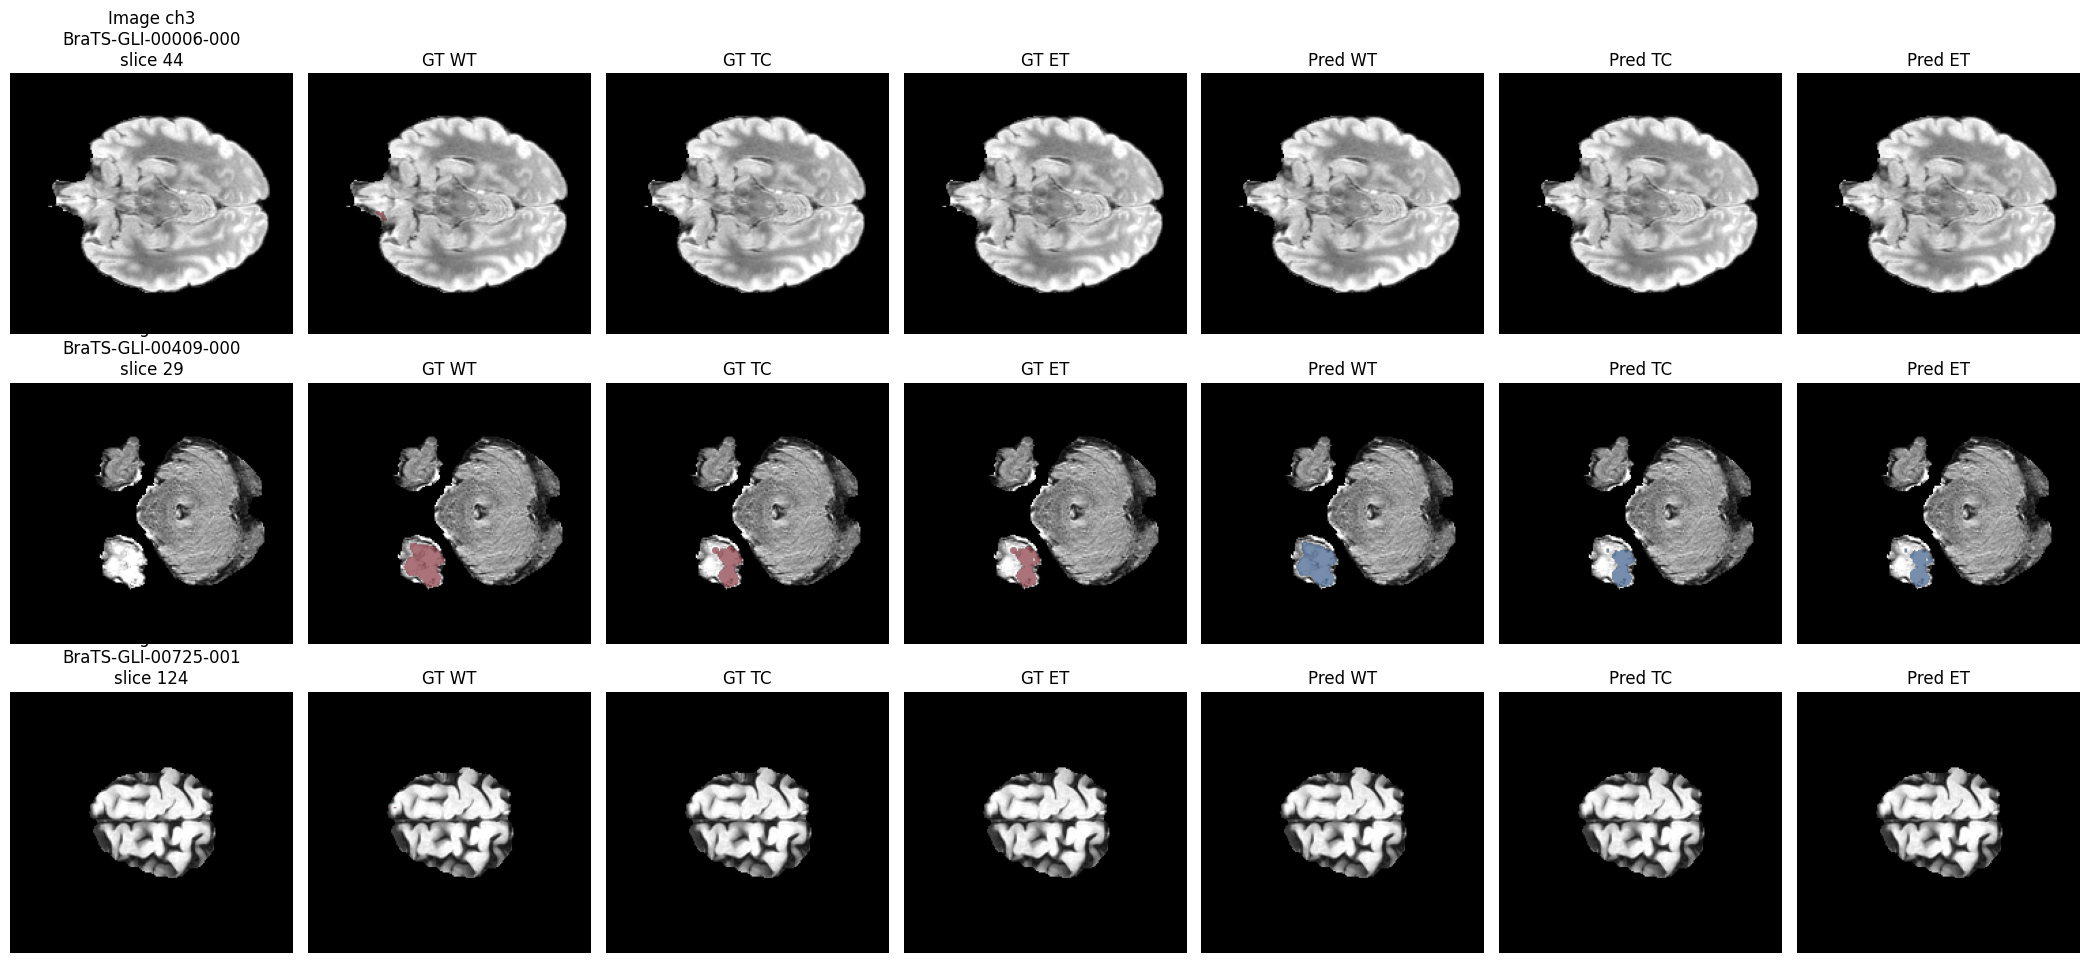

Epoch 16/80


LR: 5.000000e-04 | Train Loss: 0.0764 | Val Loss: 0.3133 | Dice WT: 0.9425 | Dice TC: 0.9069 | Dice ET: 0.9132 | Mean Dice: 0.9209
Early stopping counter: 0/20
Saved new best model. Mean Dice = 0.9209
Epoch 17/80


LR: 5.000000e-04 | Train Loss: 0.0769 | Val Loss: 0.3120 | Dice WT: 0.9435 | Dice TC: 0.9097 | Dice ET: 0.9095 | Mean Dice: 0.9209
Early stopping counter: 1/20
Epoch 18/80


LR: 5.000000e-04 | Train Loss: 0.0754 | Val Loss: 0.3133 | Dice WT: 0.9431 | Dice TC: 0.9053 | Dice ET: 0.9096 | Mean Dice: 0.9193
Early stopping counter: 2/20
Epoch 19/80


LR: 5.000000e-04 | Train Loss: 0.0744 | Val Loss: 0.3146 | Dice WT: 0.9425 | Dice TC: 0.9046 | Dice ET: 0.9049 | Mean Dice: 0.9173
Early stopping counter: 3/20
Epoch 20/80


LR: 5.000000e-04 | Train Loss: 0.0746 | Val Loss: 0.3076 | Dice WT: 0.9435 | Dice TC: 0.9150 | Dice ET: 0.9126 | Mean Dice: 0.9237
Early stopping counter: 0/20
Saved new best model. Mean Dice = 0.9237


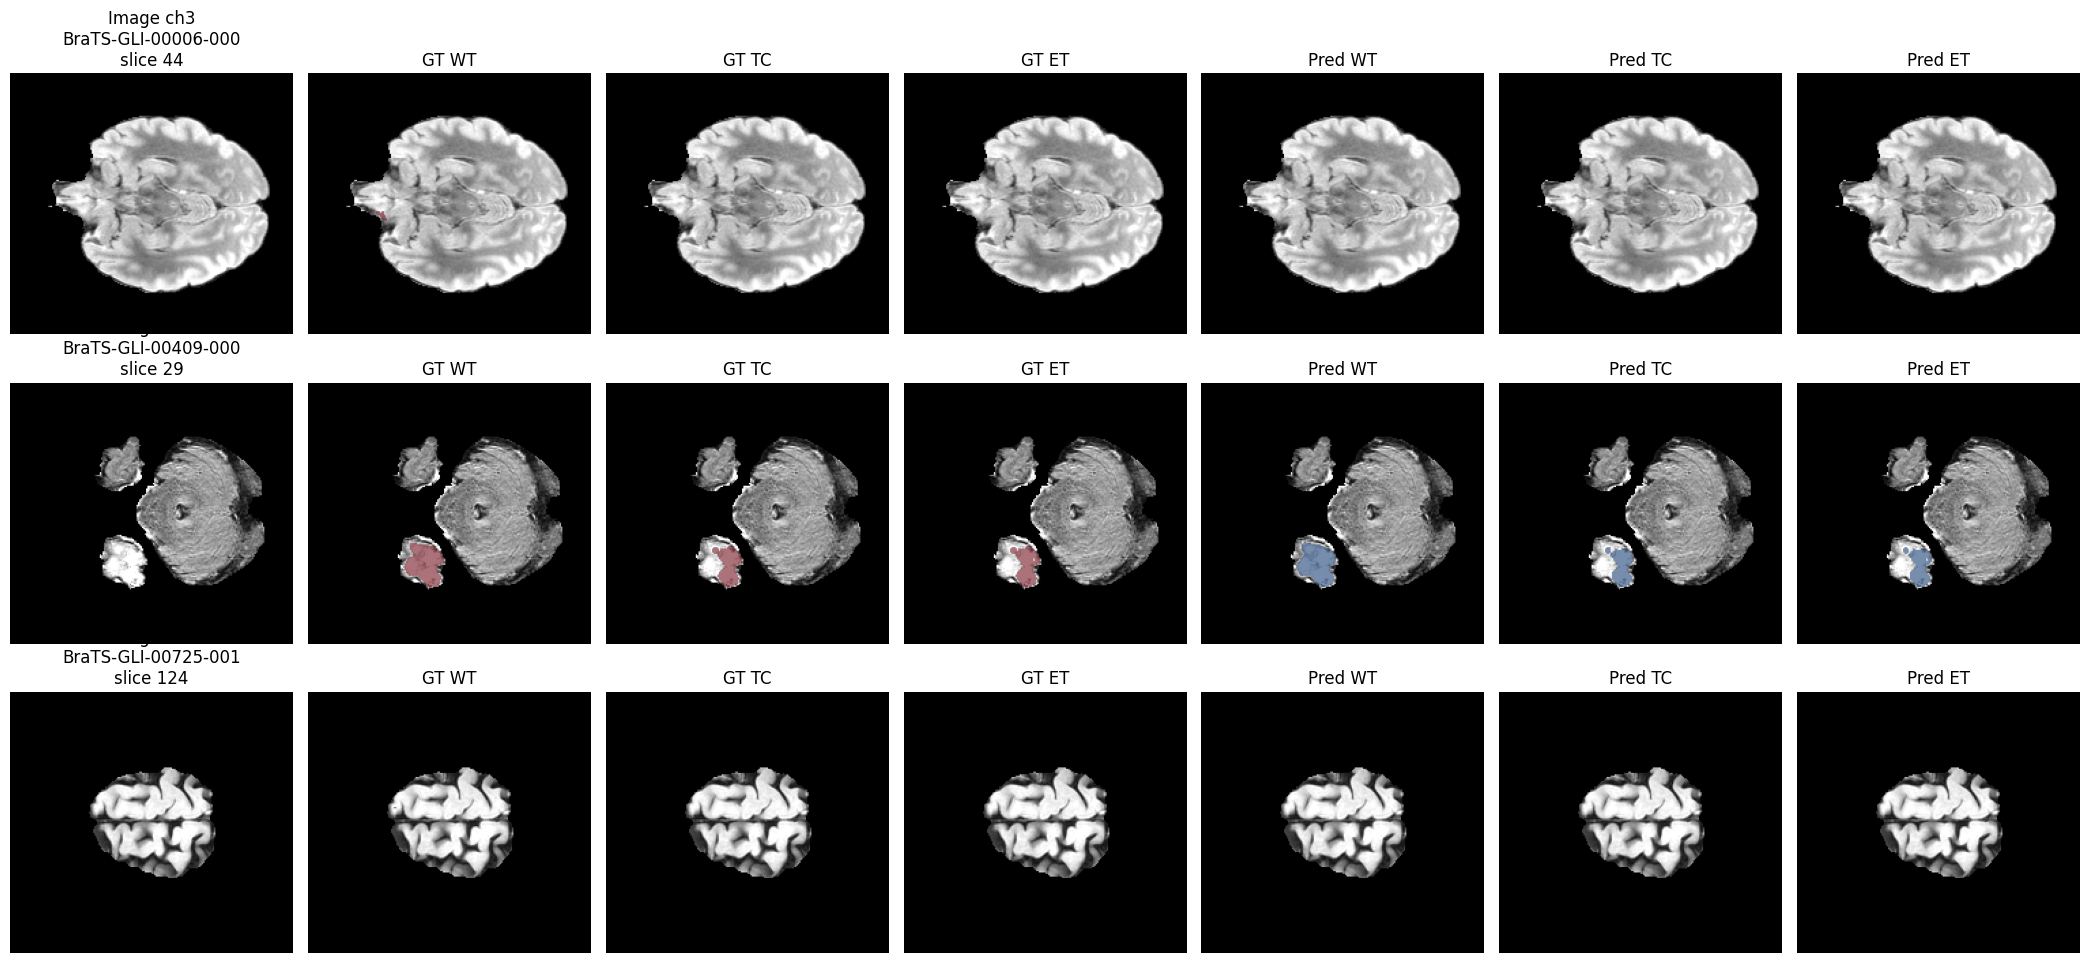

Epoch 21/80


LR: 5.000000e-04 | Train Loss: 0.0739 | Val Loss: 0.3101 | Dice WT: 0.9432 | Dice TC: 0.9101 | Dice ET: 0.9122 | Mean Dice: 0.9218
Early stopping counter: 1/20
Epoch 22/80


LR: 5.000000e-04 | Train Loss: 0.0731 | Val Loss: 0.3064 | Dice WT: 0.9430 | Dice TC: 0.9069 | Dice ET: 0.9131 | Mean Dice: 0.9210
Early stopping counter: 2/20
Epoch 23/80


LR: 5.000000e-04 | Train Loss: 0.0729 | Val Loss: 0.3132 | Dice WT: 0.9430 | Dice TC: 0.9097 | Dice ET: 0.9120 | Mean Dice: 0.9216
Early stopping counter: 3/20
Epoch 24/80


LR: 5.000000e-04 | Train Loss: 0.0720 | Val Loss: 0.3090 | Dice WT: 0.9428 | Dice TC: 0.9093 | Dice ET: 0.9120 | Mean Dice: 0.9214
Early stopping counter: 4/20
Epoch 25/80


LR: 5.000000e-04 | Train Loss: 0.0718 | Val Loss: 0.3122 | Dice WT: 0.9433 | Dice TC: 0.9099 | Dice ET: 0.9090 | Mean Dice: 0.9207
Early stopping counter: 5/20


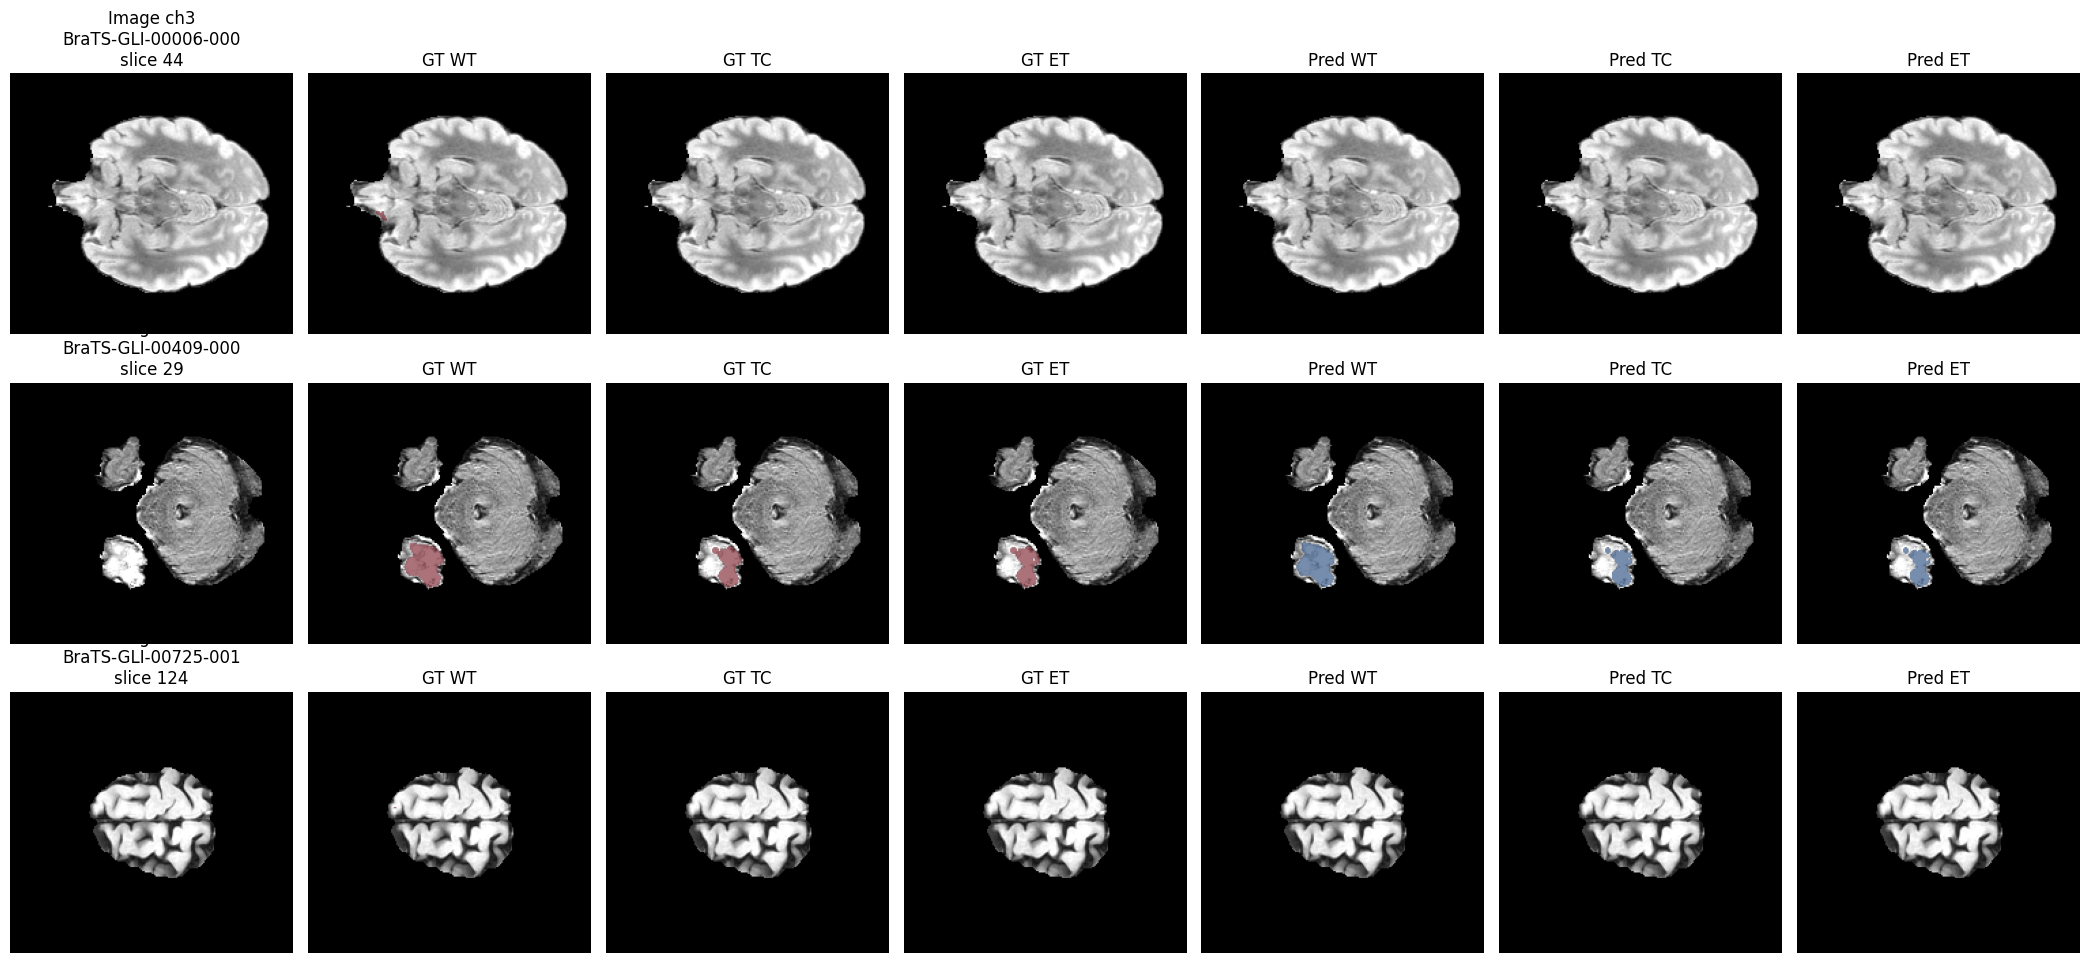

Epoch 26/80


LR: 2.500000e-04 | Train Loss: 0.0712 | Val Loss: 0.3086 | Dice WT: 0.9415 | Dice TC: 0.9164 | Dice ET: 0.9122 | Mean Dice: 0.9234
Early stopping counter: 6/20
Epoch 27/80


LR: 2.500000e-04 | Train Loss: 0.0697 | Val Loss: 0.3084 | Dice WT: 0.9441 | Dice TC: 0.9147 | Dice ET: 0.9143 | Mean Dice: 0.9244
Early stopping counter: 0/20
Saved new best model. Mean Dice = 0.9244
Epoch 28/80


LR: 2.500000e-04 | Train Loss: 0.0681 | Val Loss: 0.3041 | Dice WT: 0.9432 | Dice TC: 0.9127 | Dice ET: 0.9139 | Mean Dice: 0.9233
Early stopping counter: 1/20
Epoch 29/80


LR: 2.500000e-04 | Train Loss: 0.0683 | Val Loss: 0.3105 | Dice WT: 0.9425 | Dice TC: 0.9122 | Dice ET: 0.9118 | Mean Dice: 0.9222
Early stopping counter: 2/20
Epoch 30/80


LR: 2.500000e-04 | Train Loss: 0.0681 | Val Loss: 0.3134 | Dice WT: 0.9419 | Dice TC: 0.9096 | Dice ET: 0.9096 | Mean Dice: 0.9204
Early stopping counter: 3/20


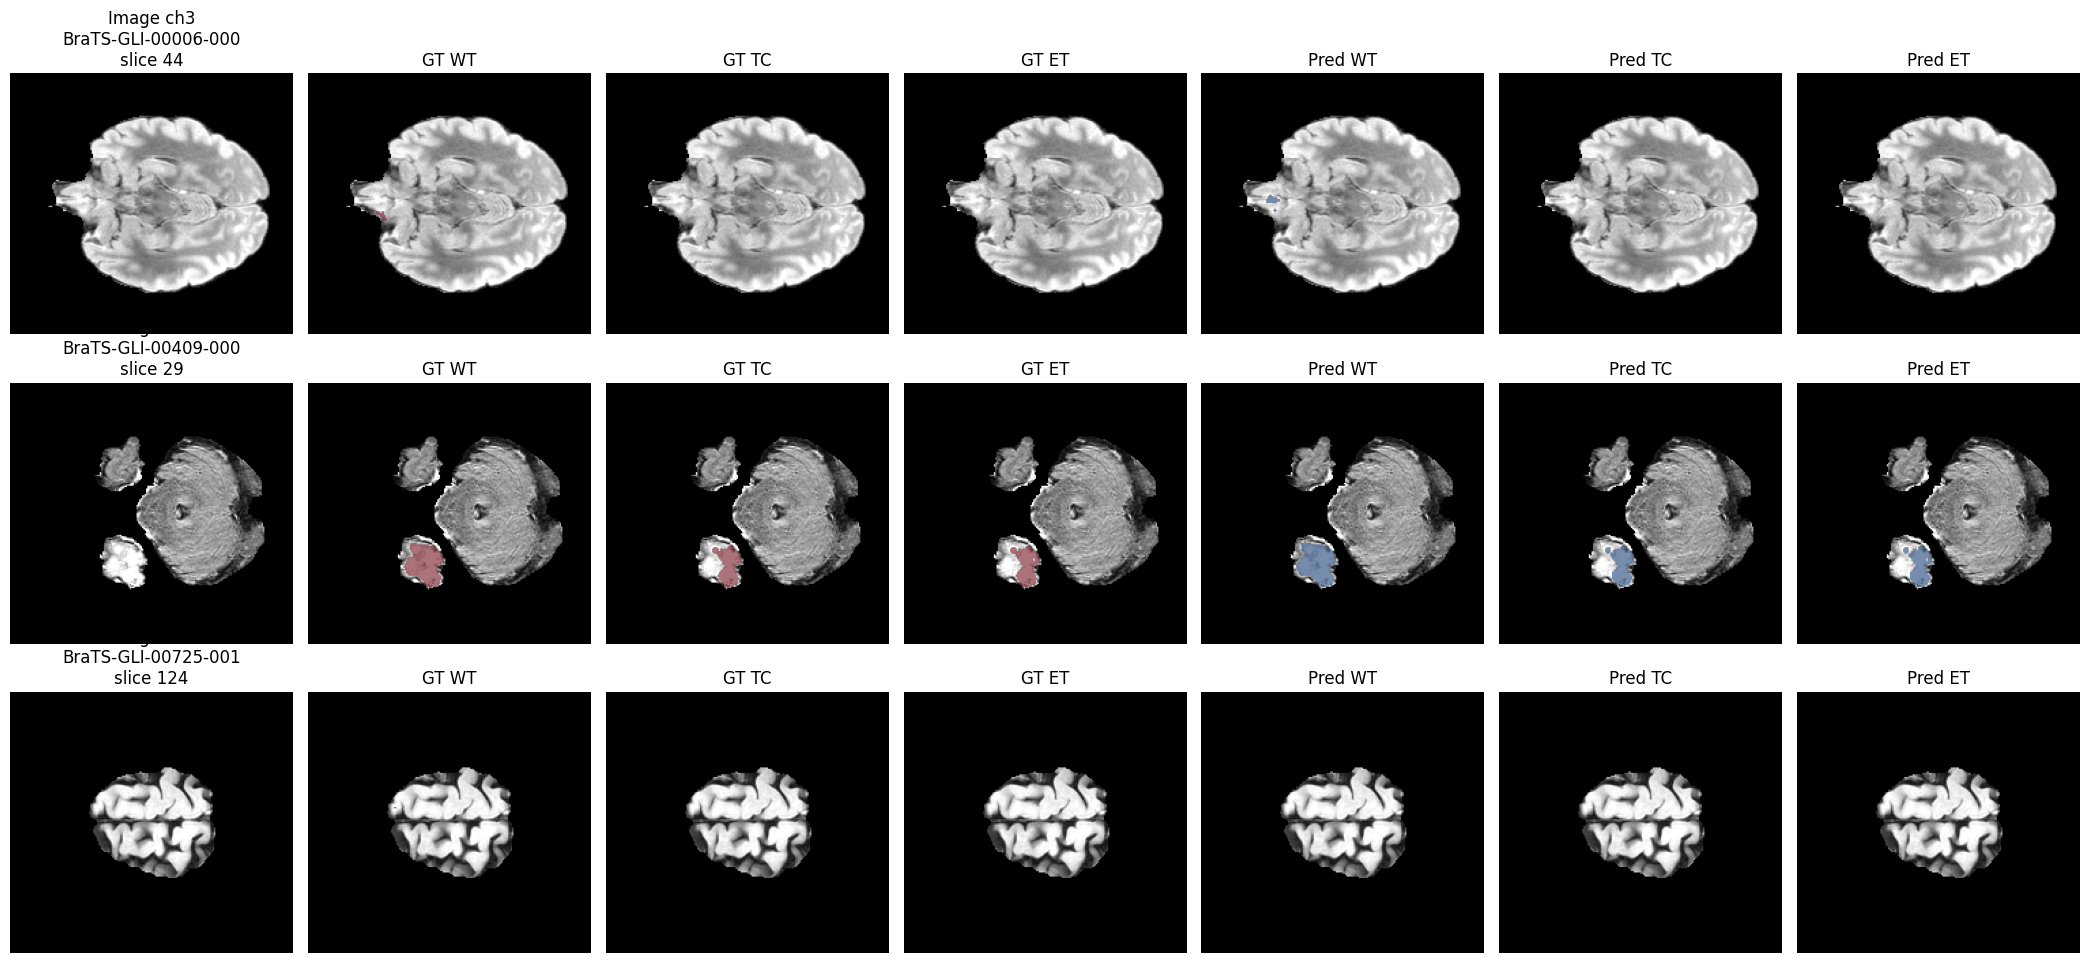

Epoch 31/80


LR: 2.500000e-04 | Train Loss: 0.0680 | Val Loss: 0.3093 | Dice WT: 0.9438 | Dice TC: 0.9096 | Dice ET: 0.9109 | Mean Dice: 0.9214
Early stopping counter: 4/20
Epoch 32/80


LR: 2.500000e-04 | Train Loss: 0.0674 | Val Loss: 0.3073 | Dice WT: 0.9435 | Dice TC: 0.9182 | Dice ET: 0.9095 | Mean Dice: 0.9237
Early stopping counter: 5/20
Epoch 33/80


LR: 1.250000e-04 | Train Loss: 0.0679 | Val Loss: 0.3093 | Dice WT: 0.9429 | Dice TC: 0.9113 | Dice ET: 0.9099 | Mean Dice: 0.9214
Early stopping counter: 6/20
Epoch 34/80


LR: 1.250000e-04 | Train Loss: 0.0660 | Val Loss: 0.3056 | Dice WT: 0.9442 | Dice TC: 0.9119 | Dice ET: 0.9132 | Mean Dice: 0.9231
Early stopping counter: 7/20
Epoch 35/80


LR: 1.250000e-04 | Train Loss: 0.0661 | Val Loss: 0.3085 | Dice WT: 0.9444 | Dice TC: 0.9110 | Dice ET: 0.9110 | Mean Dice: 0.9222
Early stopping counter: 8/20


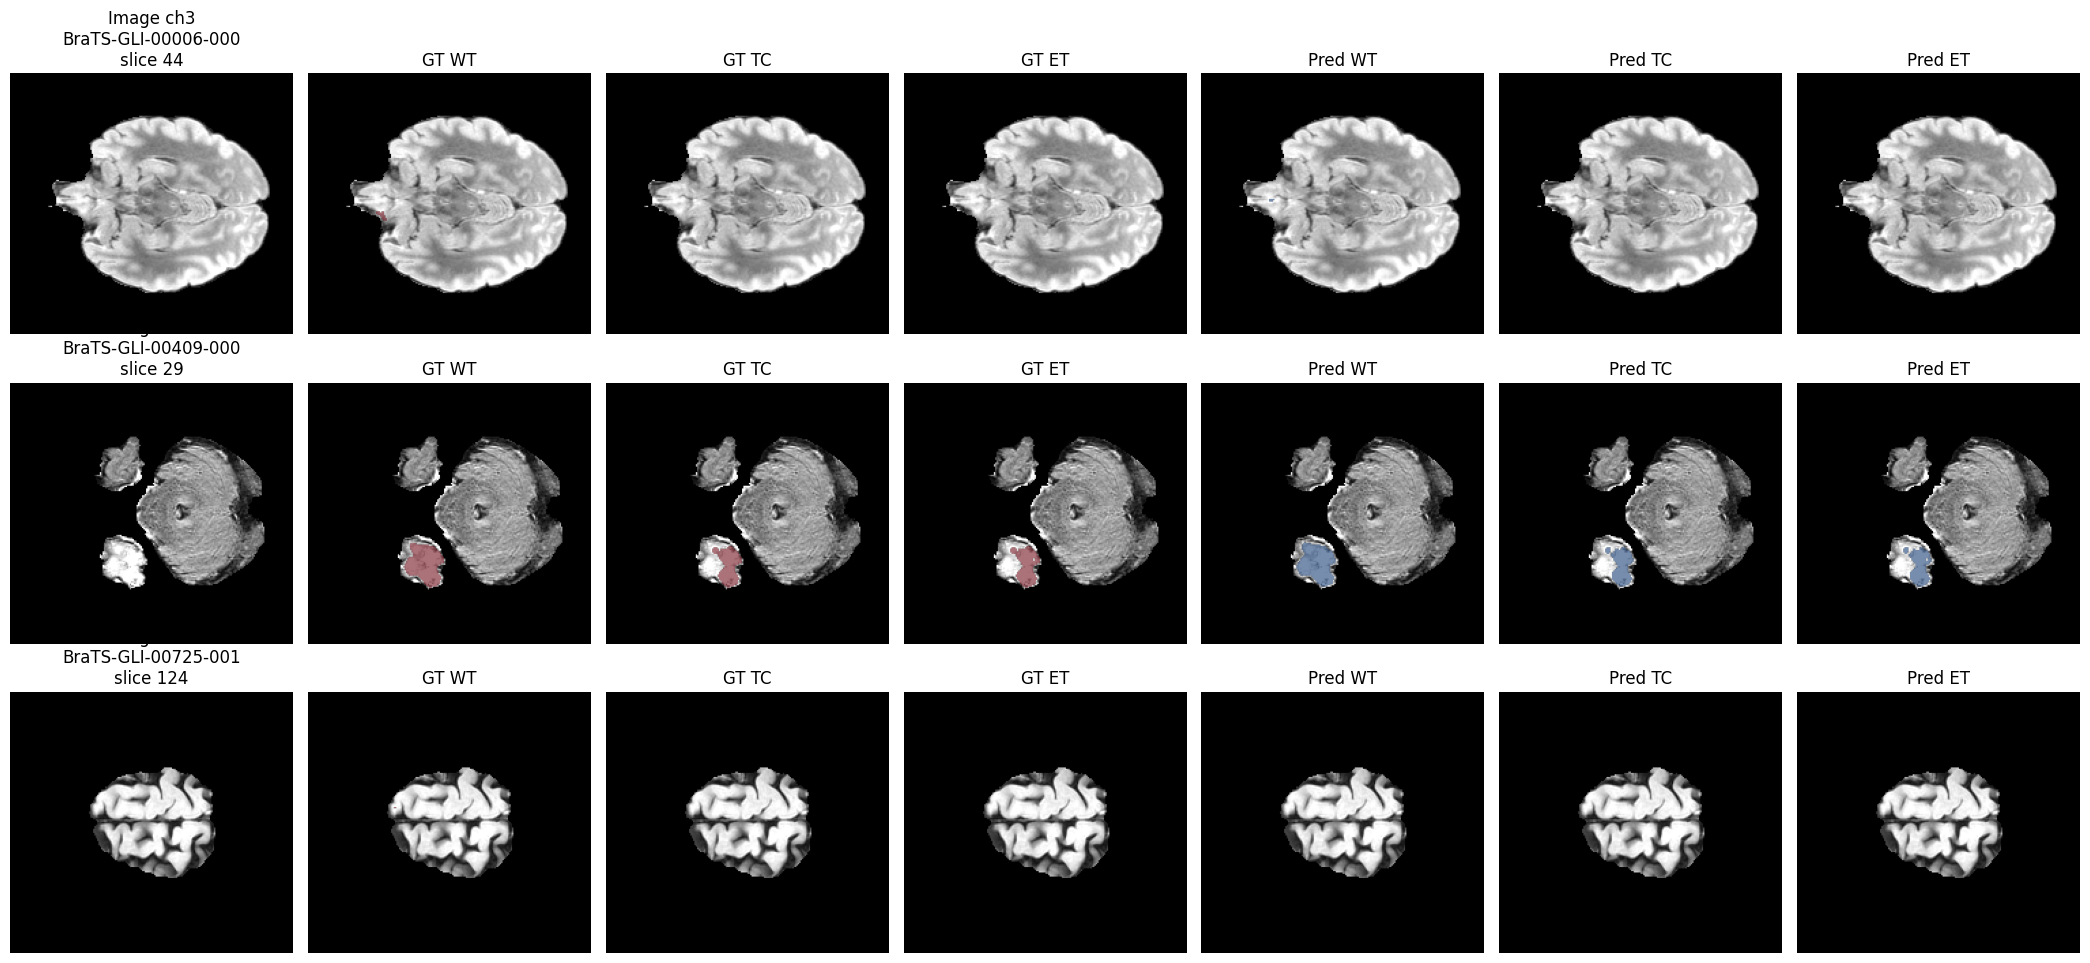

Epoch 36/80


LR: 1.250000e-04 | Train Loss: 0.0659 | Val Loss: 0.3087 | Dice WT: 0.9436 | Dice TC: 0.9107 | Dice ET: 0.9103 | Mean Dice: 0.9215
Early stopping counter: 9/20
Epoch 37/80


LR: 1.250000e-04 | Train Loss: 0.0658 | Val Loss: 0.3060 | Dice WT: 0.9446 | Dice TC: 0.9103 | Dice ET: 0.9126 | Mean Dice: 0.9225
Early stopping counter: 10/20
Epoch 38/80


LR: 1.250000e-04 | Train Loss: 0.0653 | Val Loss: 0.3065 | Dice WT: 0.9443 | Dice TC: 0.9116 | Dice ET: 0.9116 | Mean Dice: 0.9225
Early stopping counter: 11/20
Epoch 39/80


LR: 6.250000e-05 | Train Loss: 0.0648 | Val Loss: 0.3065 | Dice WT: 0.9435 | Dice TC: 0.9110 | Dice ET: 0.9139 | Mean Dice: 0.9228
Early stopping counter: 12/20
Epoch 40/80


LR: 6.250000e-05 | Train Loss: 0.0648 | Val Loss: 0.3062 | Dice WT: 0.9443 | Dice TC: 0.9119 | Dice ET: 0.9129 | Mean Dice: 0.9230
Early stopping counter: 13/20


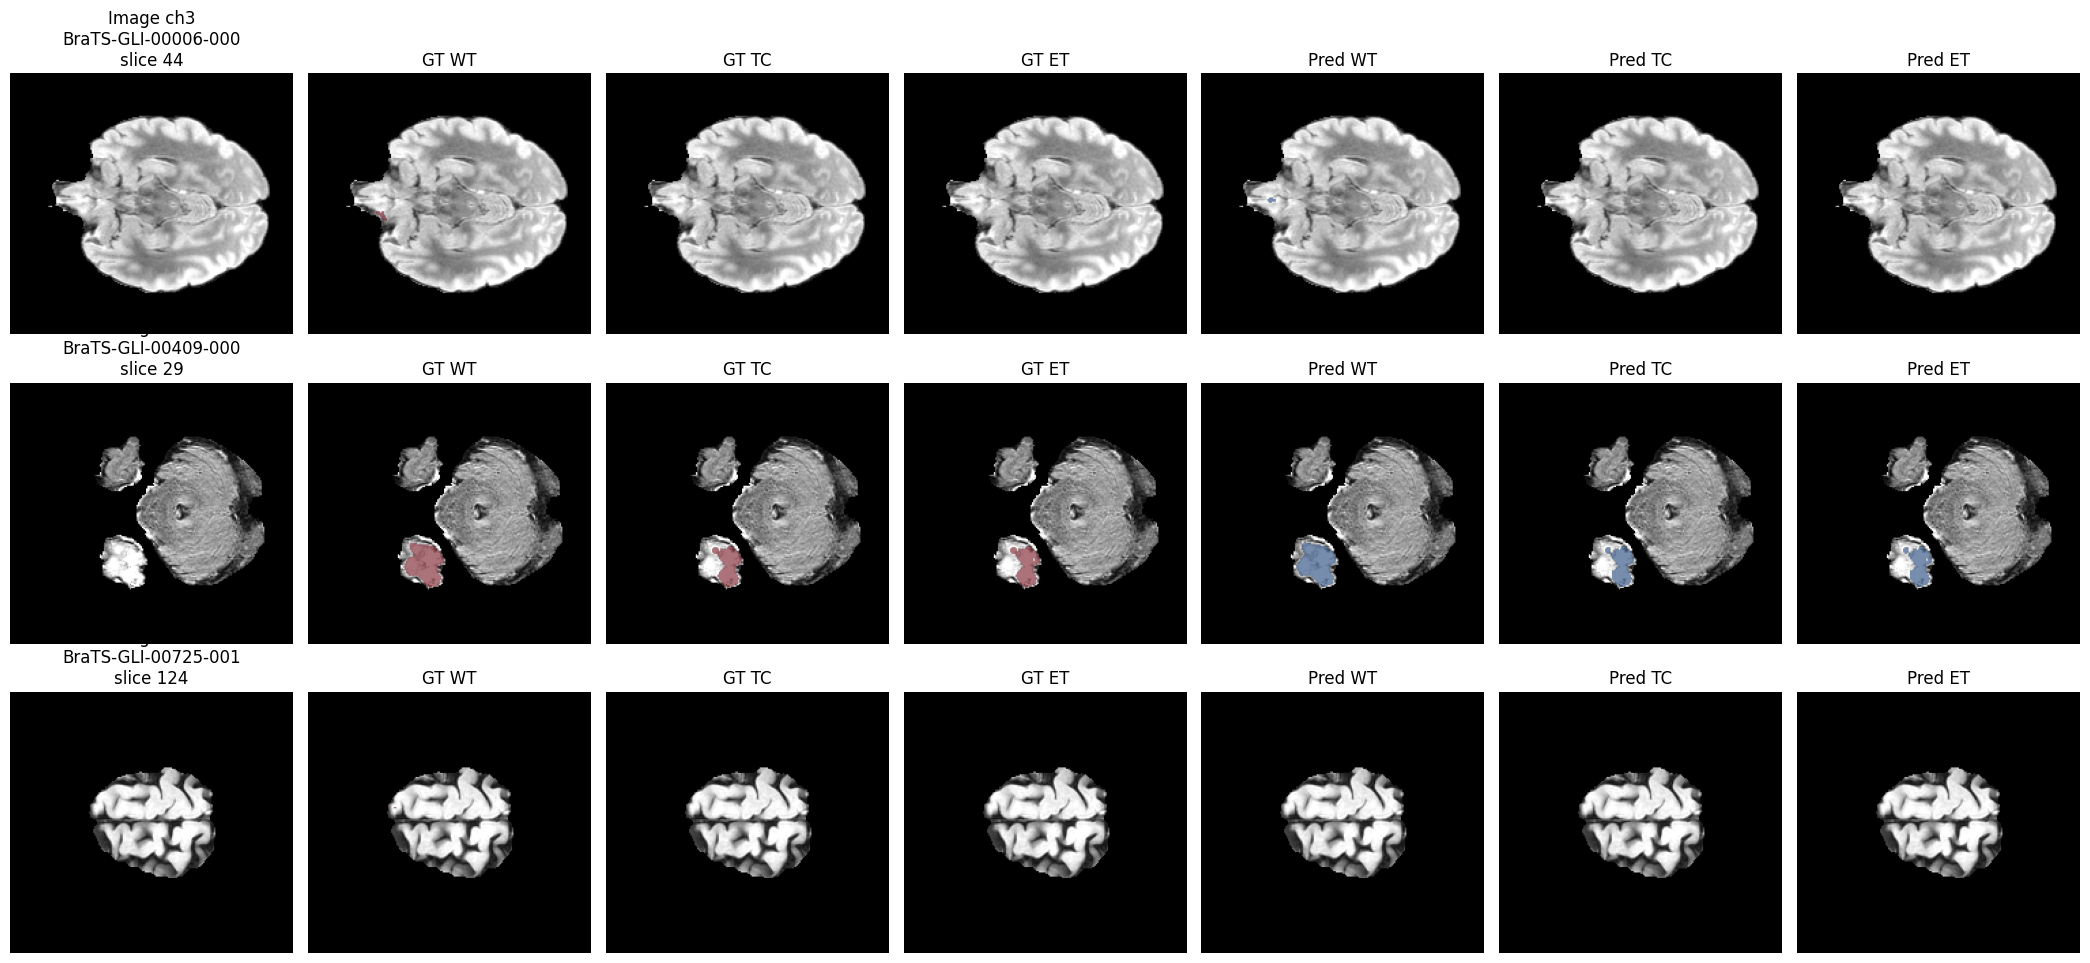

Epoch 41/80


LR: 6.250000e-05 | Train Loss: 0.0644 | Val Loss: 0.3038 | Dice WT: 0.9444 | Dice TC: 0.9160 | Dice ET: 0.9130 | Mean Dice: 0.9245
Early stopping counter: 0/20
Saved new best model. Mean Dice = 0.9245
Epoch 42/80


LR: 6.250000e-05 | Train Loss: 0.0643 | Val Loss: 0.3061 | Dice WT: 0.9445 | Dice TC: 0.9156 | Dice ET: 0.9128 | Mean Dice: 0.9243
Early stopping counter: 1/20
Epoch 43/80


LR: 6.250000e-05 | Train Loss: 0.0639 | Val Loss: 0.3077 | Dice WT: 0.9436 | Dice TC: 0.9121 | Dice ET: 0.9117 | Mean Dice: 0.9224
Early stopping counter: 2/20
Epoch 44/80


LR: 6.250000e-05 | Train Loss: 0.0641 | Val Loss: 0.3055 | Dice WT: 0.9445 | Dice TC: 0.9137 | Dice ET: 0.9138 | Mean Dice: 0.9240
Early stopping counter: 3/20
Epoch 45/80


LR: 6.250000e-05 | Train Loss: 0.0639 | Val Loss: 0.3055 | Dice WT: 0.9446 | Dice TC: 0.9123 | Dice ET: 0.9121 | Mean Dice: 0.9230
Early stopping counter: 4/20


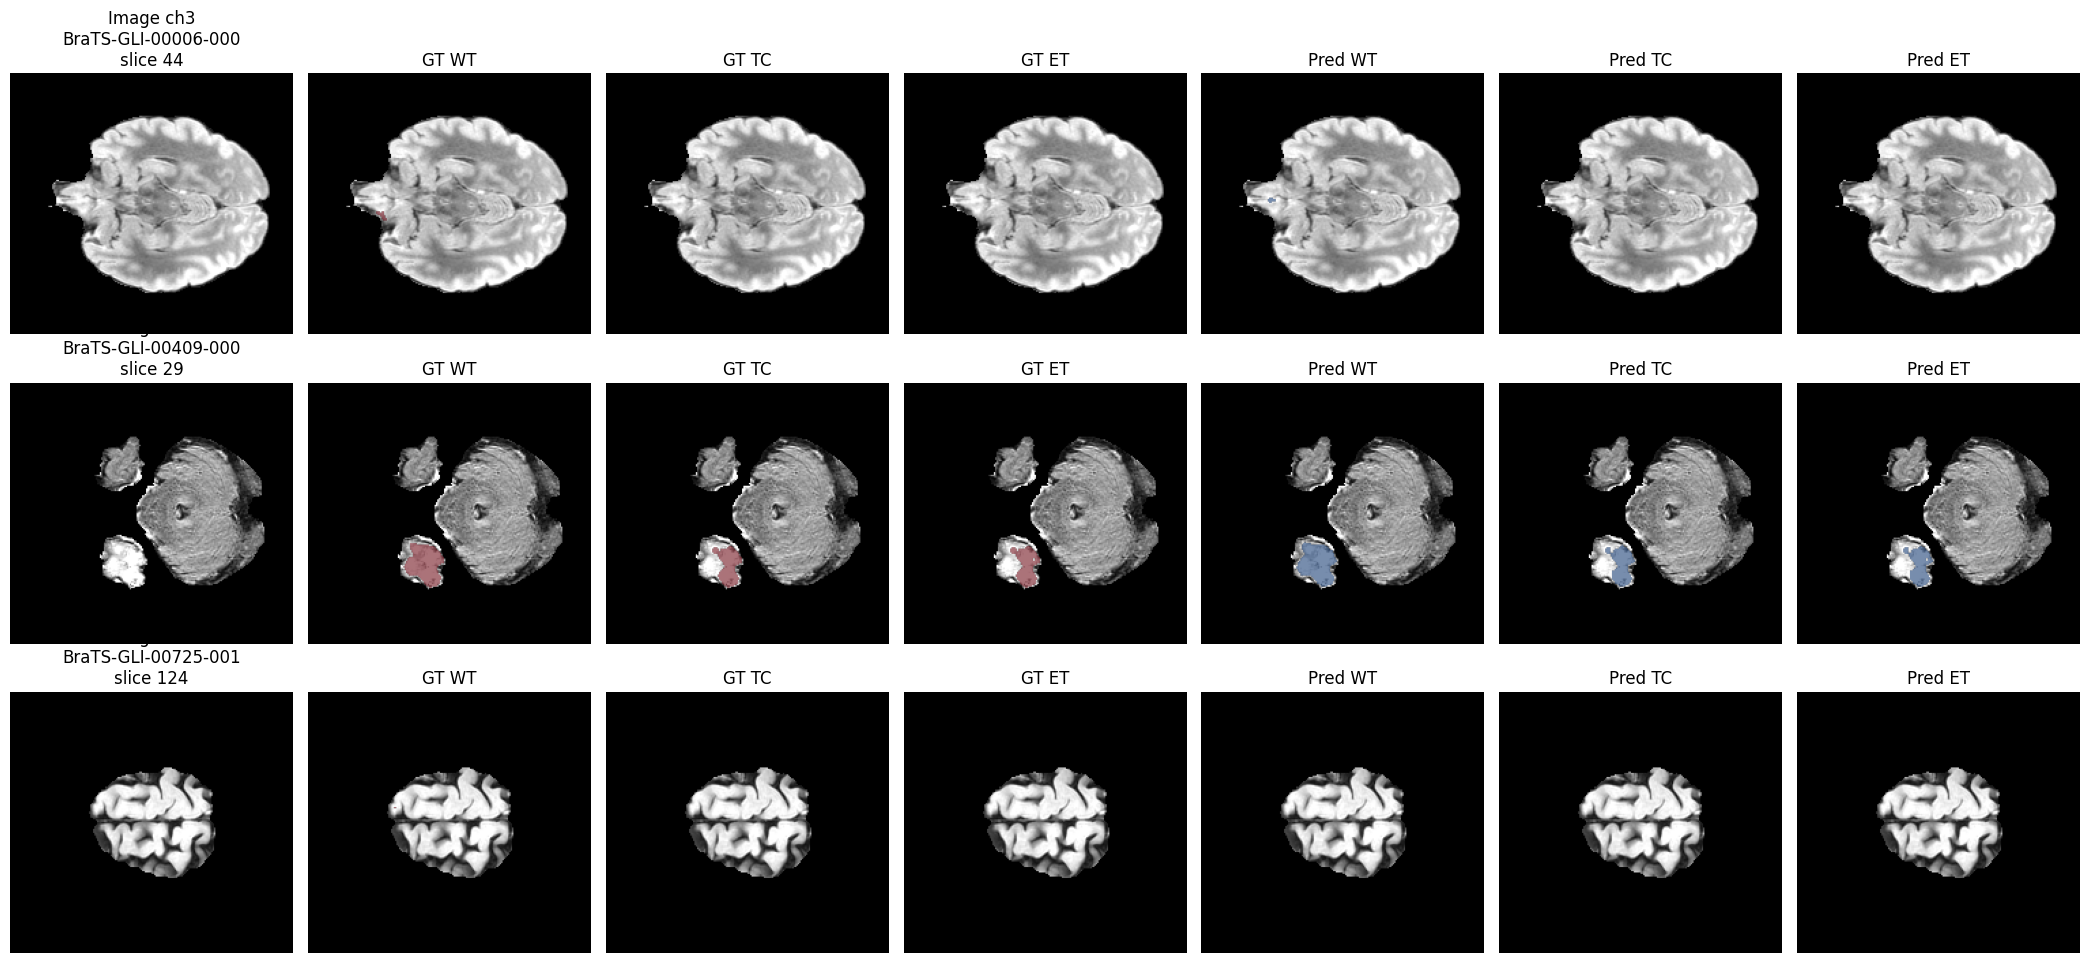

Epoch 46/80


LR: 6.250000e-05 | Train Loss: 0.0638 | Val Loss: 0.3052 | Dice WT: 0.9445 | Dice TC: 0.9115 | Dice ET: 0.9125 | Mean Dice: 0.9228
Early stopping counter: 5/20
Epoch 47/80


LR: 3.125000e-05 | Train Loss: 0.0636 | Val Loss: 0.3071 | Dice WT: 0.9442 | Dice TC: 0.9138 | Dice ET: 0.9100 | Mean Dice: 0.9226
Early stopping counter: 6/20
Epoch 48/80


LR: 3.125000e-05 | Train Loss: 0.0637 | Val Loss: 0.3058 | Dice WT: 0.9447 | Dice TC: 0.9118 | Dice ET: 0.9110 | Mean Dice: 0.9225
Early stopping counter: 7/20
Epoch 49/80


LR: 3.125000e-05 | Train Loss: 0.0636 | Val Loss: 0.3049 | Dice WT: 0.9442 | Dice TC: 0.9141 | Dice ET: 0.9122 | Mean Dice: 0.9235
Early stopping counter: 8/20
Epoch 50/80


LR: 3.125000e-05 | Train Loss: 0.0634 | Val Loss: 0.3058 | Dice WT: 0.9445 | Dice TC: 0.9124 | Dice ET: 0.9123 | Mean Dice: 0.9230
Early stopping counter: 9/20


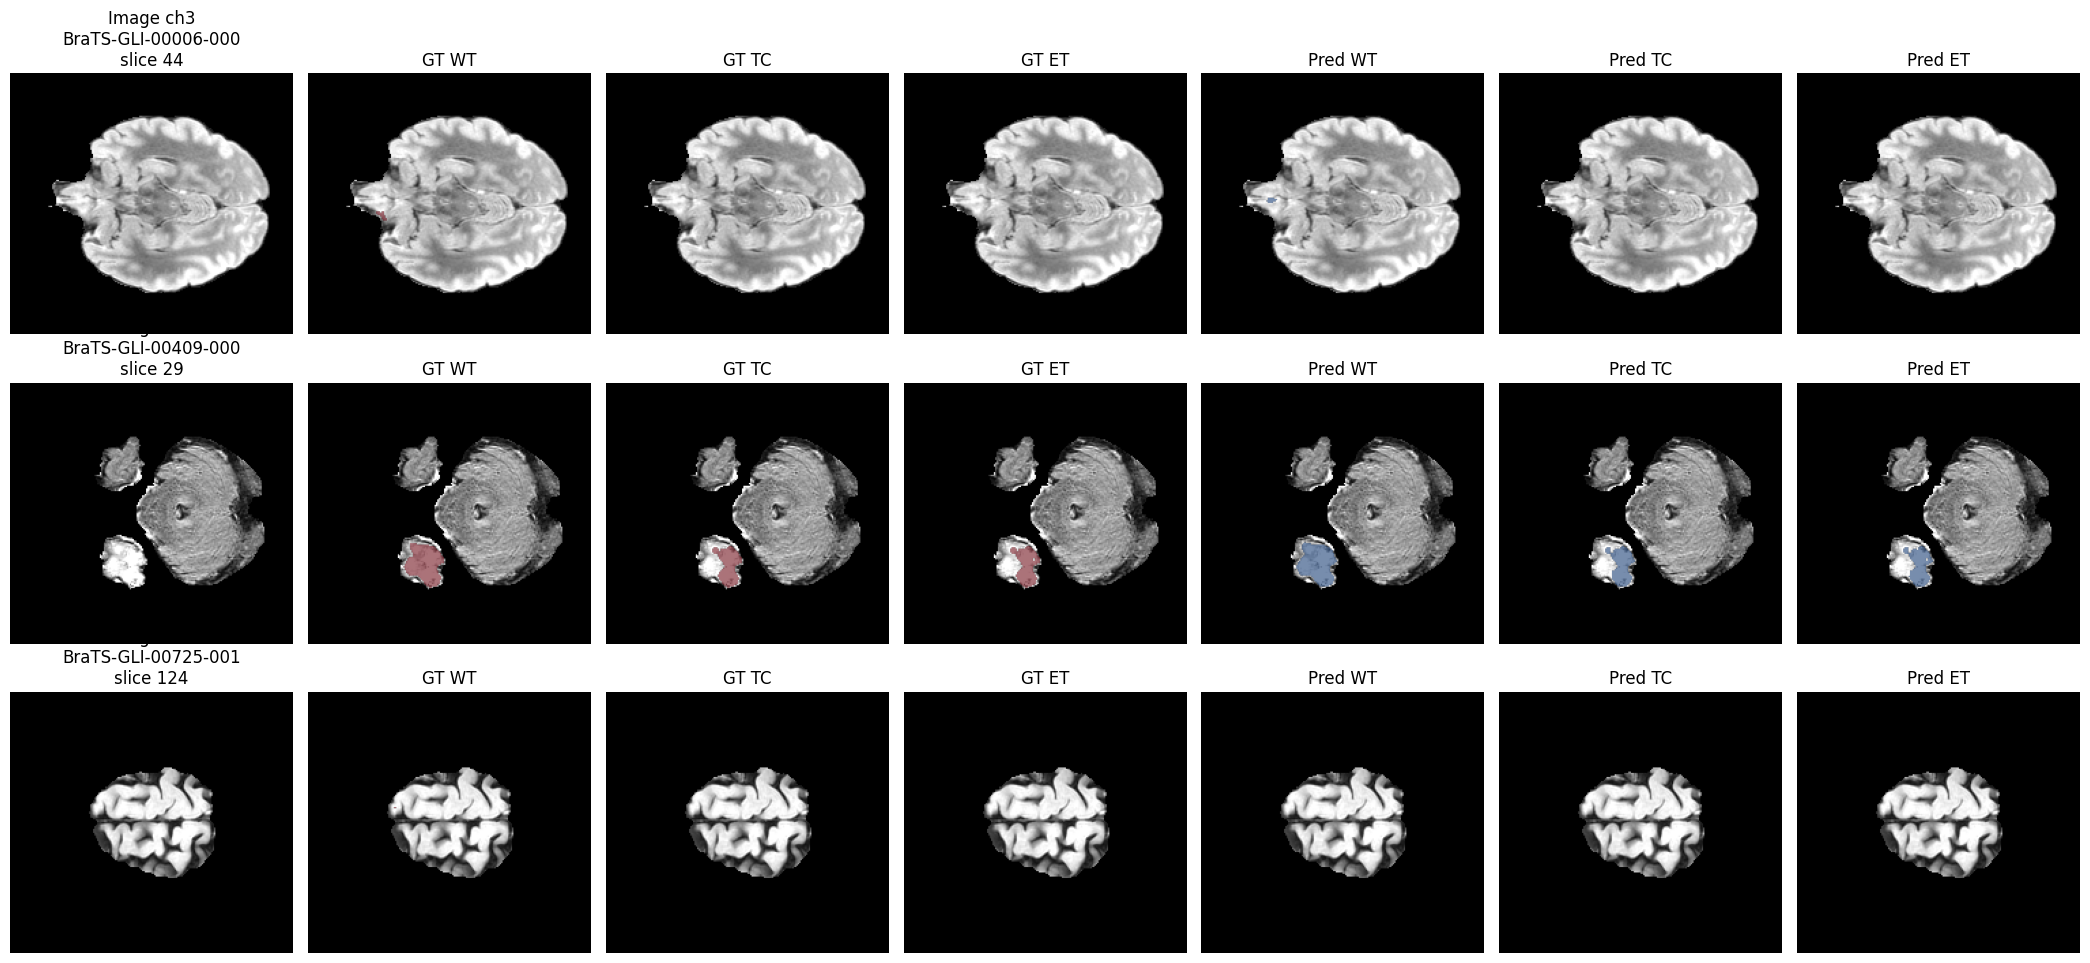

Epoch 51/80


LR: 3.125000e-05 | Train Loss: 0.0631 | Val Loss: 0.3060 | Dice WT: 0.9447 | Dice TC: 0.9119 | Dice ET: 0.9122 | Mean Dice: 0.9230
Early stopping counter: 10/20
Epoch 52/80


LR: 3.125000e-05 | Train Loss: 0.0634 | Val Loss: 0.3057 | Dice WT: 0.9447 | Dice TC: 0.9135 | Dice ET: 0.9127 | Mean Dice: 0.9236
Early stopping counter: 11/20
Epoch 53/80


LR: 1.562500e-05 | Train Loss: 0.0635 | Val Loss: 0.3063 | Dice WT: 0.9441 | Dice TC: 0.9125 | Dice ET: 0.9129 | Mean Dice: 0.9232
Early stopping counter: 12/20
Epoch 54/80


LR: 1.562500e-05 | Train Loss: 0.0628 | Val Loss: 0.3037 | Dice WT: 0.9445 | Dice TC: 0.9157 | Dice ET: 0.9134 | Mean Dice: 0.9245
Early stopping counter: 0/20
Saved new best model. Mean Dice = 0.9245
Epoch 55/80


LR: 1.562500e-05 | Train Loss: 0.0636 | Val Loss: 0.3057 | Dice WT: 0.9439 | Dice TC: 0.9116 | Dice ET: 0.9126 | Mean Dice: 0.9227
Early stopping counter: 1/20


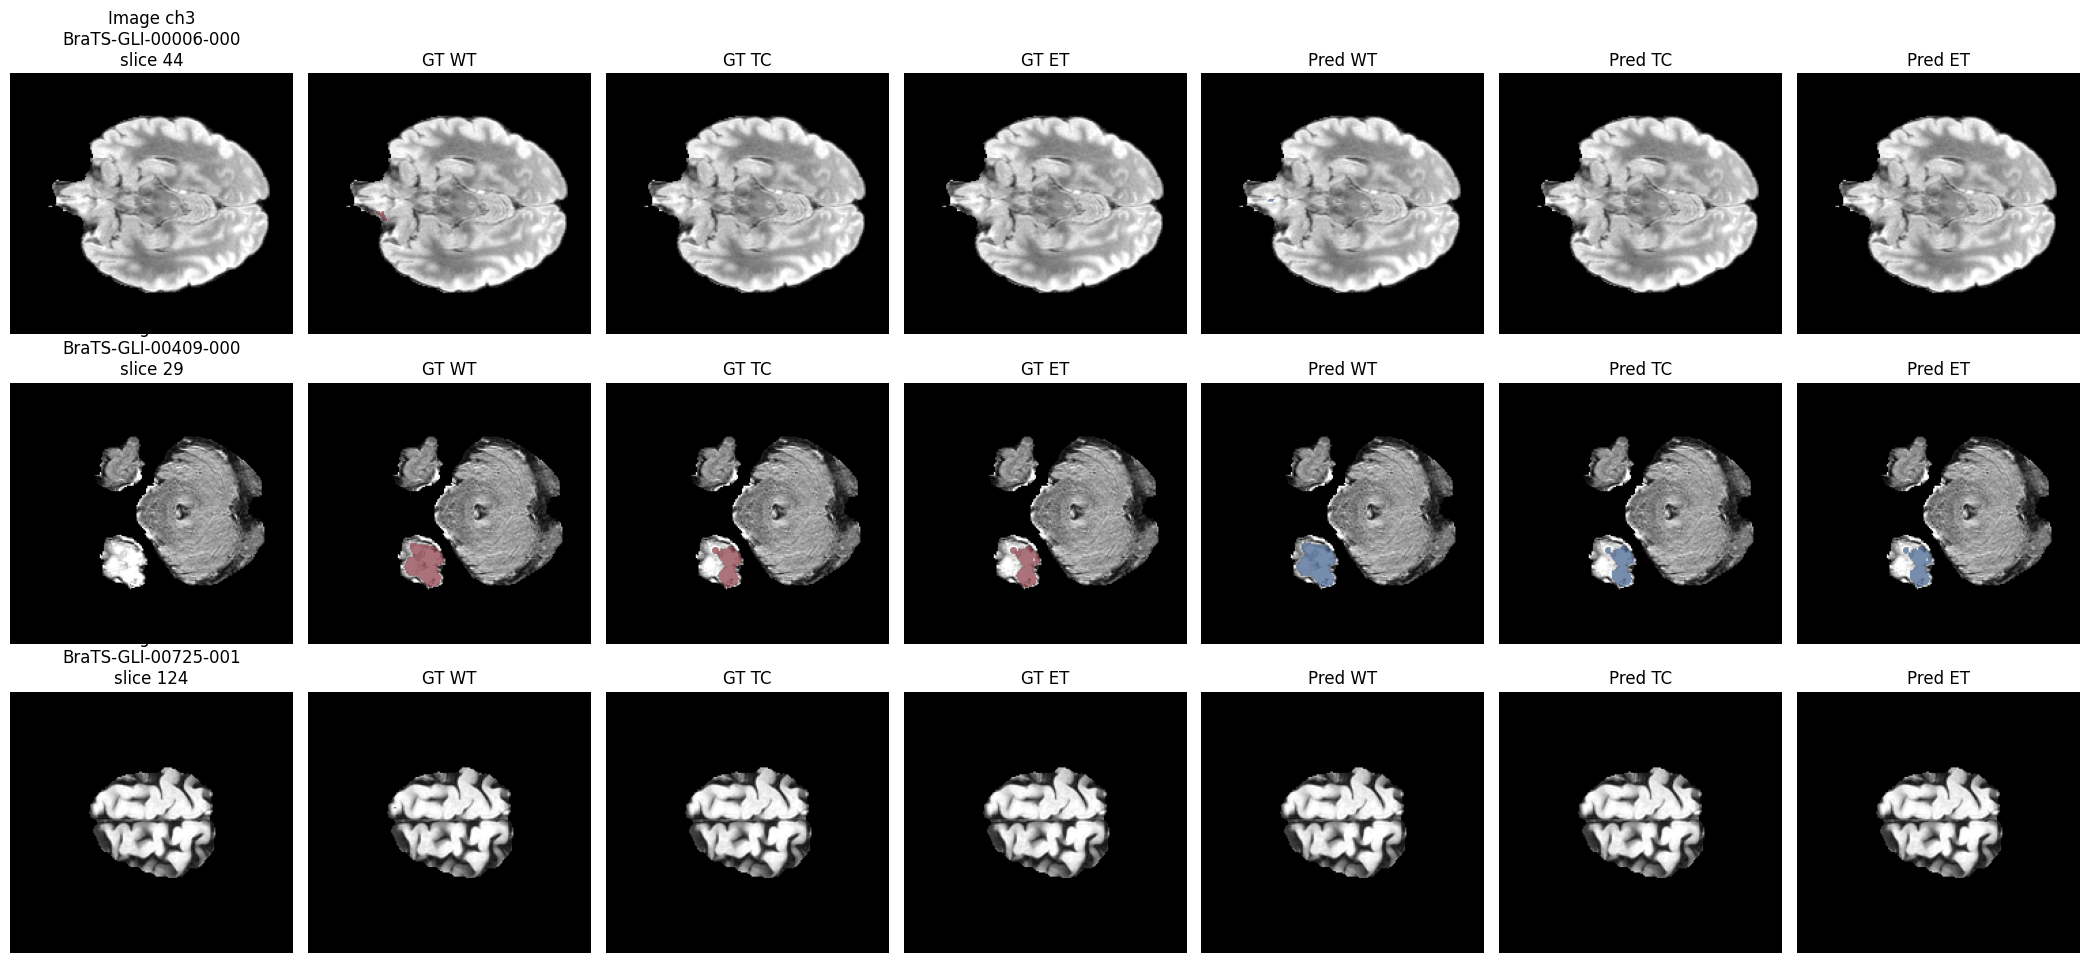

Epoch 56/80


LR: 1.562500e-05 | Train Loss: 0.0634 | Val Loss: 0.3051 | Dice WT: 0.9446 | Dice TC: 0.9135 | Dice ET: 0.9117 | Mean Dice: 0.9232
Early stopping counter: 2/20
Epoch 57/80


LR: 1.562500e-05 | Train Loss: 0.0628 | Val Loss: 0.3037 | Dice WT: 0.9447 | Dice TC: 0.9137 | Dice ET: 0.9133 | Mean Dice: 0.9239
Early stopping counter: 3/20
Epoch 58/80


LR: 1.562500e-05 | Train Loss: 0.0630 | Val Loss: 0.3057 | Dice WT: 0.9446 | Dice TC: 0.9133 | Dice ET: 0.9125 | Mean Dice: 0.9235
Early stopping counter: 4/20
Epoch 59/80


LR: 7.812500e-06 | Train Loss: 0.0633 | Val Loss: 0.3045 | Dice WT: 0.9445 | Dice TC: 0.9136 | Dice ET: 0.9128 | Mean Dice: 0.9236
Early stopping counter: 5/20
Epoch 60/80


LR: 7.812500e-06 | Train Loss: 0.0631 | Val Loss: 0.3052 | Dice WT: 0.9445 | Dice TC: 0.9137 | Dice ET: 0.9128 | Mean Dice: 0.9237
Early stopping counter: 6/20


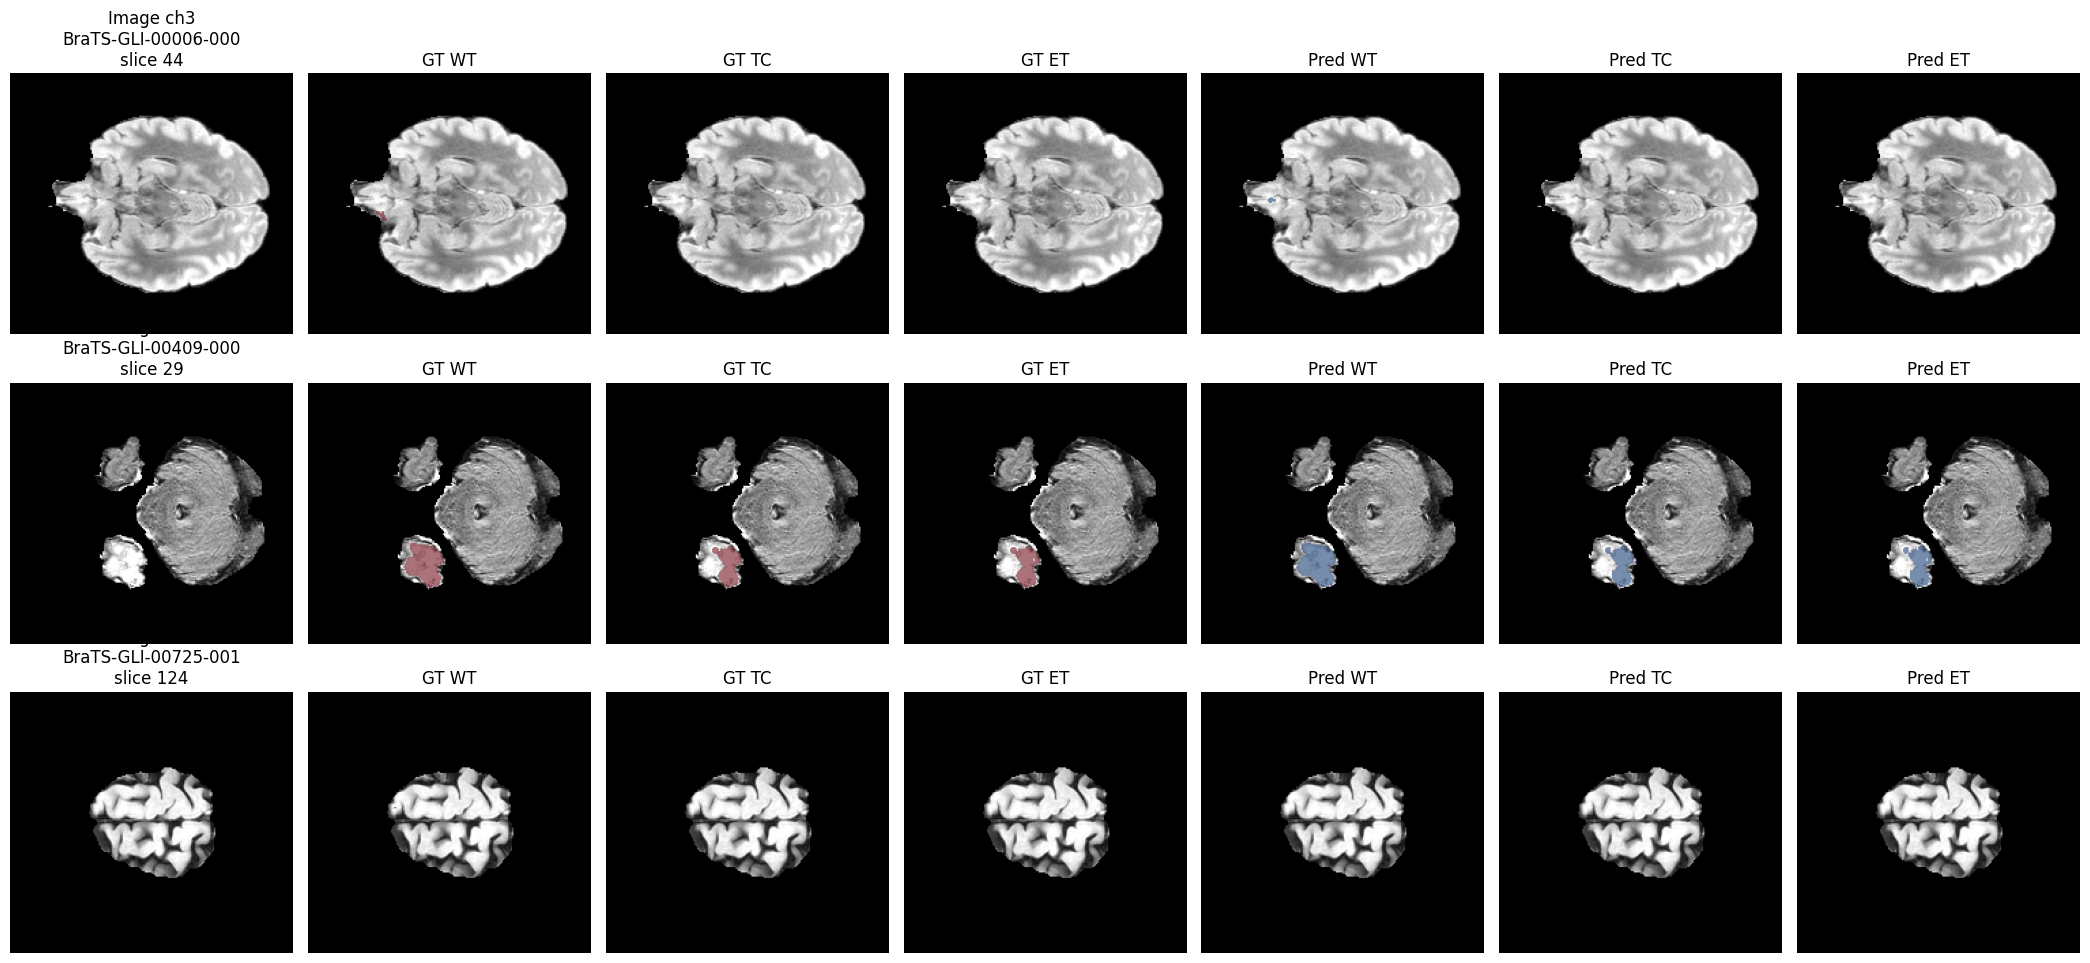

Epoch 61/80


LR: 7.812500e-06 | Train Loss: 0.0631 | Val Loss: 0.3050 | Dice WT: 0.9448 | Dice TC: 0.9145 | Dice ET: 0.9117 | Mean Dice: 0.9237
Early stopping counter: 7/20
Epoch 62/80


LR: 7.812500e-06 | Train Loss: 0.0628 | Val Loss: 0.3043 | Dice WT: 0.9446 | Dice TC: 0.9145 | Dice ET: 0.9128 | Mean Dice: 0.9240
Early stopping counter: 8/20
Epoch 63/80


LR: 7.812500e-06 | Train Loss: 0.0629 | Val Loss: 0.3057 | Dice WT: 0.9446 | Dice TC: 0.9126 | Dice ET: 0.9125 | Mean Dice: 0.9232
Early stopping counter: 9/20
Epoch 64/80


LR: 7.812500e-06 | Train Loss: 0.0629 | Val Loss: 0.3048 | Dice WT: 0.9443 | Dice TC: 0.9135 | Dice ET: 0.9125 | Mean Dice: 0.9234
Early stopping counter: 10/20
Epoch 65/80


LR: 3.906250e-06 | Train Loss: 0.0634 | Val Loss: 0.3054 | Dice WT: 0.9445 | Dice TC: 0.9120 | Dice ET: 0.9116 | Mean Dice: 0.9227
Early stopping counter: 11/20


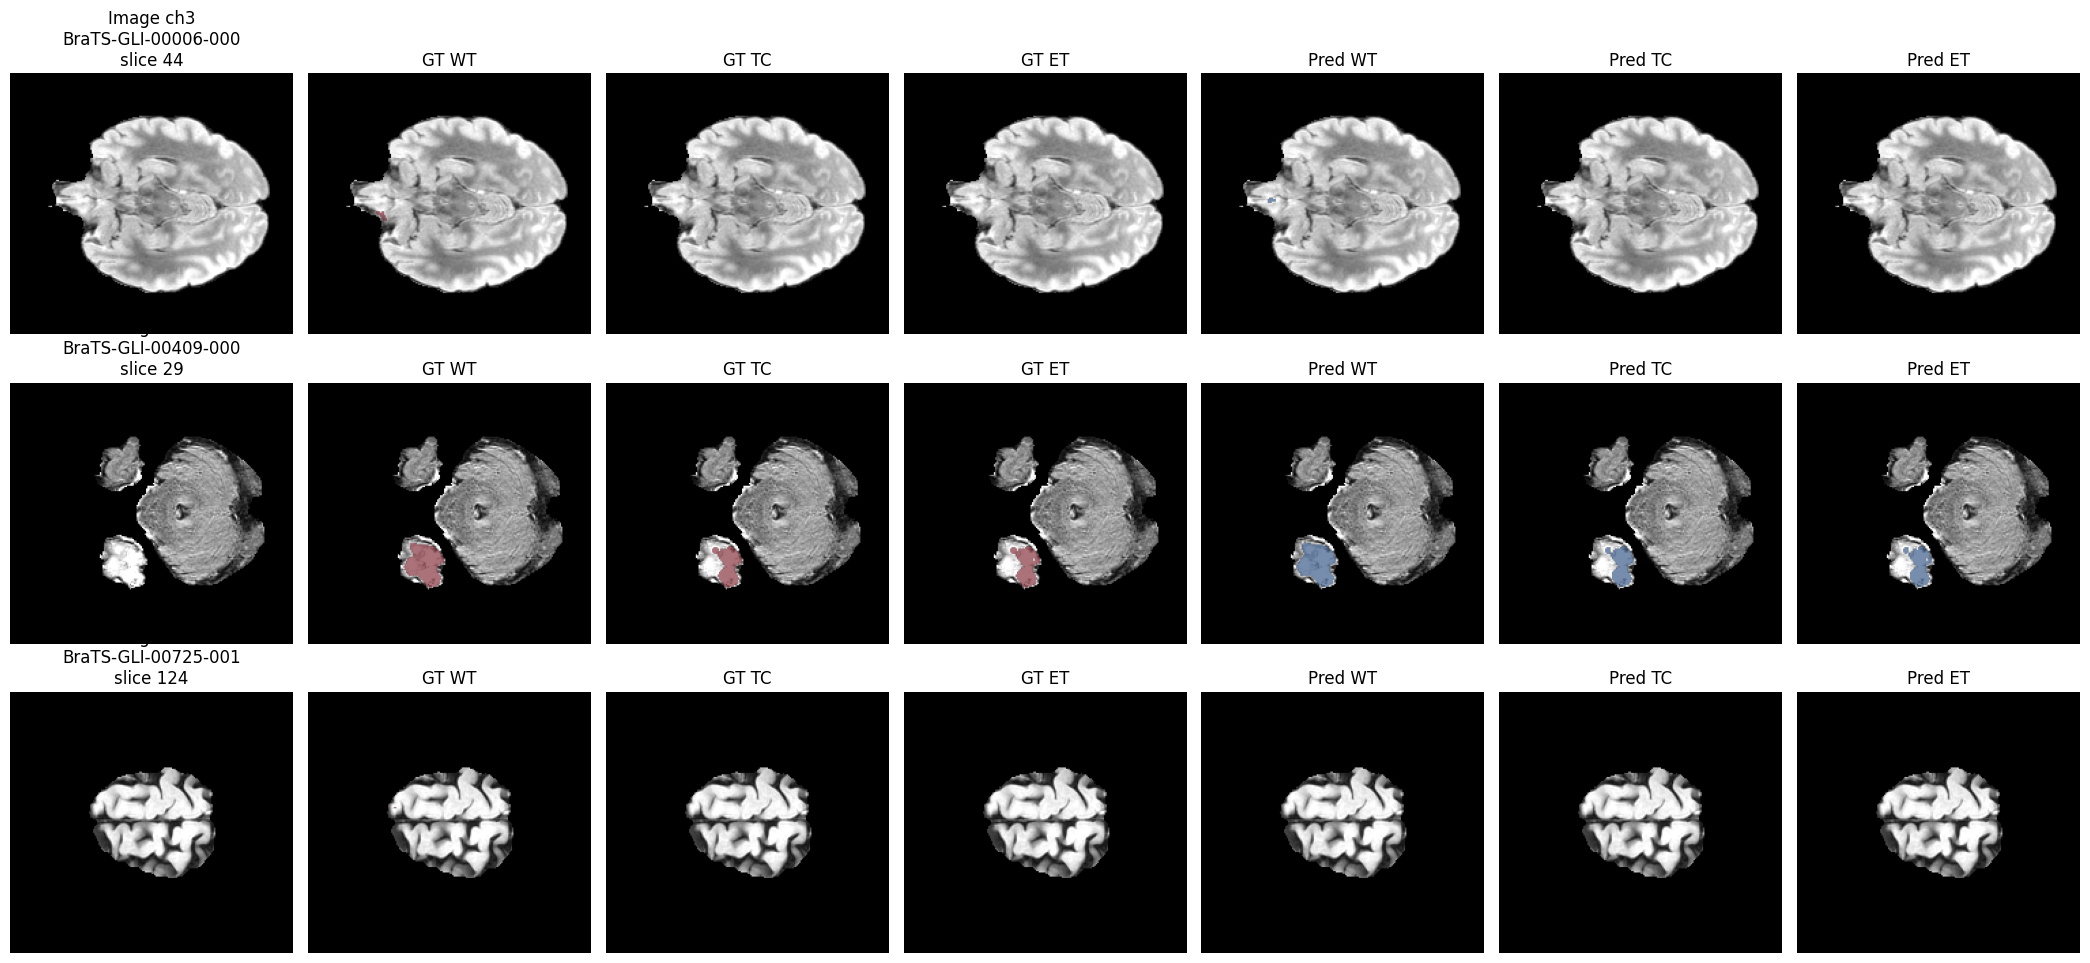

Epoch 66/80


LR: 3.906250e-06 | Train Loss: 0.0628 | Val Loss: 0.3041 | Dice WT: 0.9446 | Dice TC: 0.9144 | Dice ET: 0.9127 | Mean Dice: 0.9239
Early stopping counter: 12/20
Epoch 67/80


LR: 3.906250e-06 | Train Loss: 0.0630 | Val Loss: 0.3052 | Dice WT: 0.9444 | Dice TC: 0.9148 | Dice ET: 0.9119 | Mean Dice: 0.9237
Early stopping counter: 13/20
Epoch 68/80


LR: 3.906250e-06 | Train Loss: 0.0631 | Val Loss: 0.3054 | Dice WT: 0.9441 | Dice TC: 0.9128 | Dice ET: 0.9125 | Mean Dice: 0.9231
Early stopping counter: 14/20
Epoch 69/80


LR: 3.906250e-06 | Train Loss: 0.0627 | Val Loss: 0.3054 | Dice WT: 0.9447 | Dice TC: 0.9133 | Dice ET: 0.9112 | Mean Dice: 0.9231
Early stopping counter: 15/20
Epoch 70/80


LR: 3.906250e-06 | Train Loss: 0.0635 | Val Loss: 0.3052 | Dice WT: 0.9444 | Dice TC: 0.9149 | Dice ET: 0.9121 | Mean Dice: 0.9238
Early stopping counter: 16/20


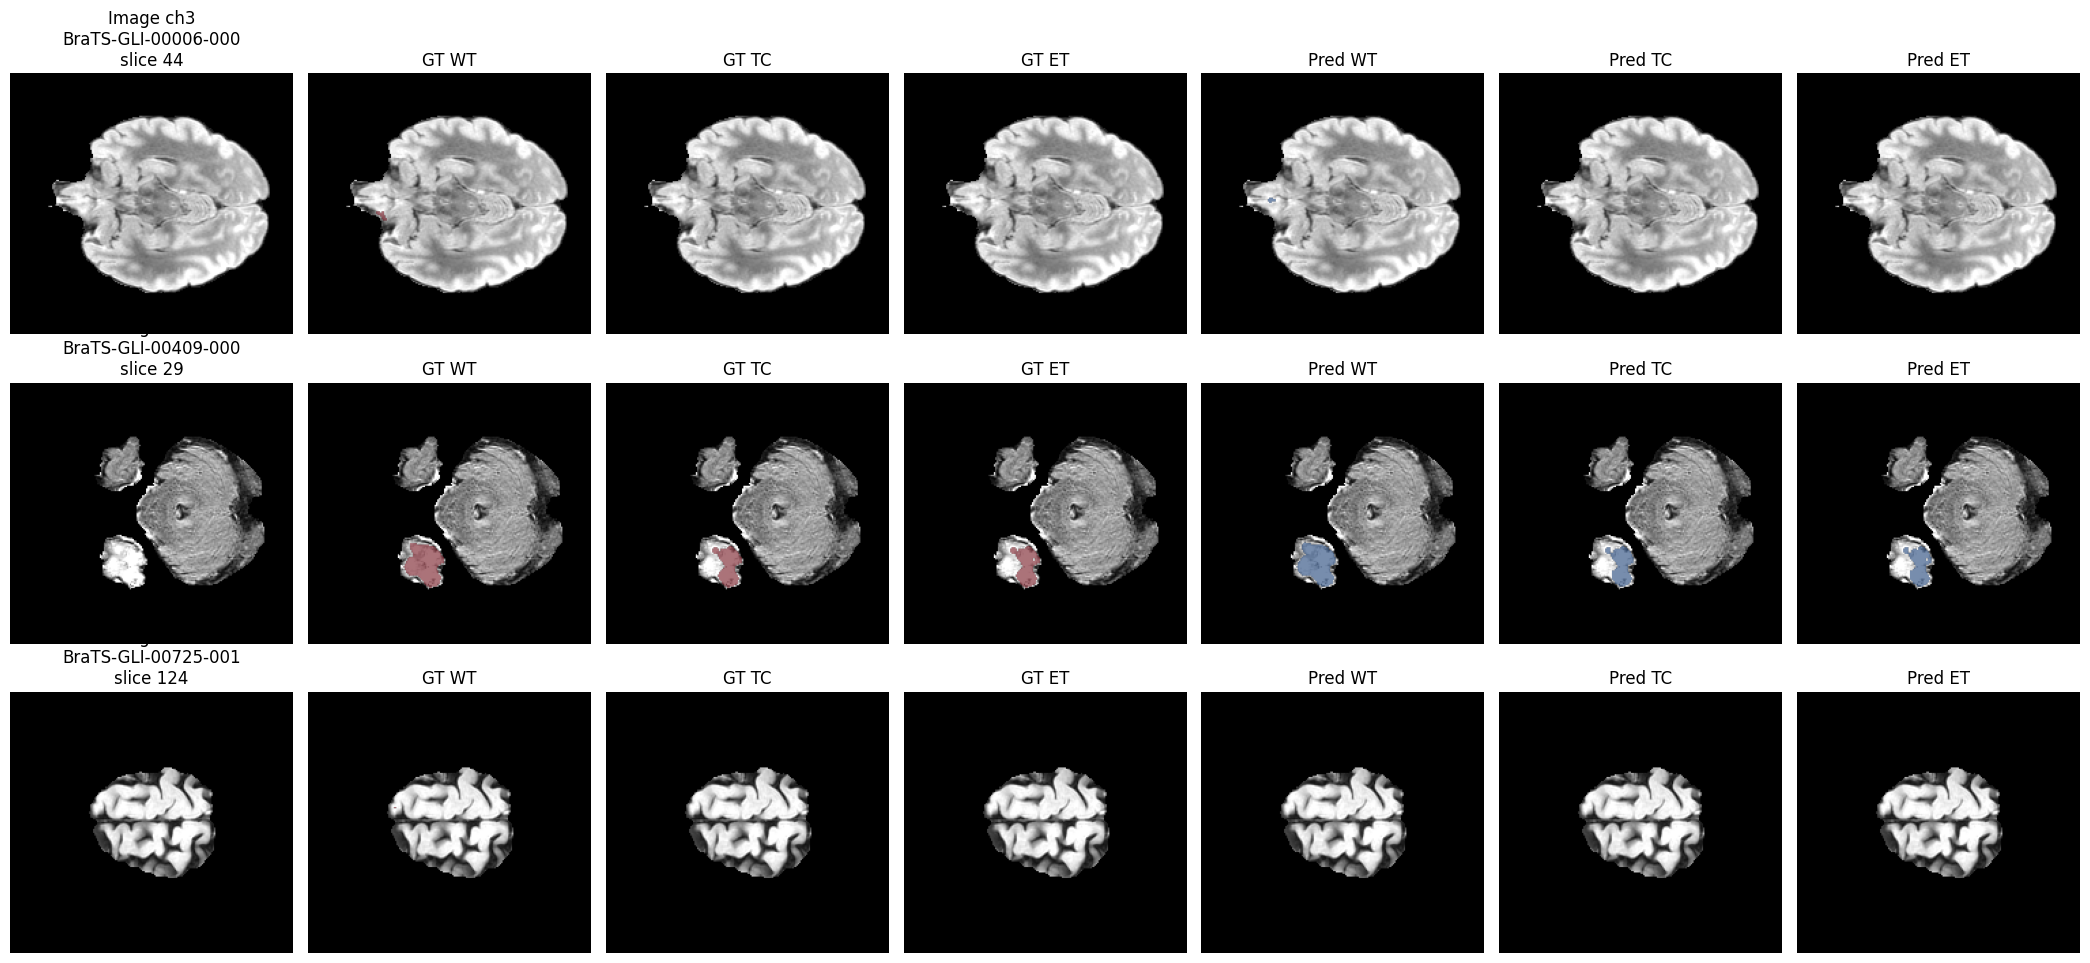

Epoch 71/80


LR: 1.953125e-06 | Train Loss: 0.0631 | Val Loss: 0.3053 | Dice WT: 0.9445 | Dice TC: 0.9127 | Dice ET: 0.9118 | Mean Dice: 0.9230
Early stopping counter: 17/20
Epoch 72/80


LR: 1.953125e-06 | Train Loss: 0.0628 | Val Loss: 0.3047 | Dice WT: 0.9444 | Dice TC: 0.9116 | Dice ET: 0.9133 | Mean Dice: 0.9231
Early stopping counter: 18/20
Epoch 73/80


LR: 1.953125e-06 | Train Loss: 0.0625 | Val Loss: 0.3048 | Dice WT: 0.9446 | Dice TC: 0.9137 | Dice ET: 0.9125 | Mean Dice: 0.9236
Early stopping counter: 19/20
Epoch 74/80


LR: 1.953125e-06 | Train Loss: 0.0631 | Val Loss: 0.3045 | Dice WT: 0.9445 | Dice TC: 0.9130 | Dice ET: 0.9120 | Mean Dice: 0.9232
Early stopping counter: 20/20
Early stopping triggered after 74 epochs. Best Mean Dice = 0.9245

Training finished.
Best Mean Dice: 0.9245
Elapsed time: 401.53 minutes
Best model: outputs_task2_unet2d\best_attention_unet.pth
Last model: outputs_task2_unet2d\last_attention_unet.pth
Training history: outputs_task2_unet2d\training_history.csv


In [ ]:
log_path = OUTPUT_DIR / "training_history.csv"
best_model_path = OUTPUT_DIR / "best_unet.pth"
last_model_path = OUTPUT_DIR / "last_unet.pth"

# If True, load last_attention_unet.pth and continue training.
RESUME_TRAINING = True

# This means total target epochs, not additional epochs.
# Example:
#   If you already trained 50 epochs and set TOTAL_EPOCHS = 80,
#   it will continue from epoch 51 to epoch 80.
TOTAL_EPOCHS = 80

RESUME_CHECKPOINT_PATH = last_model_path

history_fieldnames = [
    "epoch",
    "learning_rate",
    "lr",
    "train_loss",
    "train_dice_loss",
    "train_bce_loss",
    "val_loss",
    "val_dice_loss",
    "val_bce_loss",
    "val_dice",
    "dice_wt",
    "dice_tc",
    "dice_et",
    "mean_dice",
]

start_epoch = 1
best_mean_dice = -1.0
epochs_without_improvement = 0
history = []


def initialize_history_file(path, fieldnames):
    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()


def append_history_row(path, fieldnames, row):
    with open(path, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writerow(row)


def get_best_mean_dice_from_log(log_path):
    if not Path(log_path).exists():
        return -1.0

    best_value = -1.0

    with open(log_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)

        for row in reader:
            for key in ("mean_dice", "val_dice"):
                if key in row:
                    try:
                        value = float(row[key])
                        best_value = max(best_value, value)
                    except ValueError:
                        pass

    return best_value


if RESUME_TRAINING and RESUME_CHECKPOINT_PATH.exists():
    print("Resuming training from checkpoint:")
    print(RESUME_CHECKPOINT_PATH)

    checkpoint = torch.load(
        RESUME_CHECKPOINT_PATH,
        map_location=DEVICE,
    )

    model.load_state_dict(checkpoint["model_state_dict"])

    if "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    checkpoint_epoch = int(checkpoint["epoch"])
    start_epoch = checkpoint_epoch + 1

    best_mean_dice = float(checkpoint.get("best_mean_dice", -1.0))
    epochs_without_improvement = int(checkpoint.get("epochs_without_improvement", 0))

    # In case best_mean_dice in last_attention_unet.pth is slightly stale,
    # recover the best value from training_history.csv.
    best_from_log = get_best_mean_dice_from_log(log_path)
    best_mean_dice = max(best_mean_dice, best_from_log)

    if not log_path.exists():
        initialize_history_file(log_path, history_fieldnames)

    print(f"Checkpoint epoch: {checkpoint_epoch}")
    print(f"Resume from epoch: {start_epoch}")
    print(f"Current best mean Dice: {best_mean_dice:.4f}")
    print(f"Early stopping patience: {EARLY_STOPPING_PATIENCE}")
    print(f"Epochs without improvement: {epochs_without_improvement}")

else:
    print("Starting training from scratch.")

    start_epoch = 1
    best_mean_dice = -1.0
    epochs_without_improvement = 0
    initialize_history_file(log_path, history_fieldnames)


if start_epoch > TOTAL_EPOCHS:
    print(
        f"Checkpoint epoch is already {start_epoch - 1}, "
        f"which is >= TOTAL_EPOCHS={TOTAL_EPOCHS}."
    )
    print("No further training will be performed.")

else:
    start_time = time.time()

    for epoch in range(start_epoch, TOTAL_EPOCHS + 1):
        print("=" * 80)
        print(f"Epoch {epoch}/{TOTAL_EPOCHS}")
        print("=" * 80)

        train_metrics = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=DEVICE,
            scaler=scaler,
        )

        val_metrics = validate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=DEVICE,
            threshold=THRESHOLD,
        )

        scheduler.step(val_metrics["mean_dice"])

        lr = get_current_lr(optimizer)

        row = {
            "epoch": epoch,
            "learning_rate": lr,
            "lr": lr,
            "train_loss": train_metrics["loss"],
            "train_dice_loss": train_metrics["dice_loss"],
            "train_bce_loss": train_metrics["bce_loss"],
            "val_loss": val_metrics["loss"],
            "val_dice_loss": val_metrics["dice_loss"],
            "val_bce_loss": val_metrics["bce_loss"],
            "val_dice": val_metrics["mean_dice"],
            "dice_wt": val_metrics["dice_wt"],
            "dice_tc": val_metrics["dice_tc"],
            "dice_et": val_metrics["dice_et"],
            "mean_dice": val_metrics["mean_dice"],
        }

        history.append(row)

        print(
            f"LR: {lr:.6e} | "
            f"Train Loss: {row['train_loss']:.4f} | "
            f"Val Loss: {row['val_loss']:.4f} | "
            f"Dice WT: {row['dice_wt']:.4f} | "
            f"Dice TC: {row['dice_tc']:.4f} | "
            f"Dice ET: {row['dice_et']:.4f} | "
            f"Mean Dice: {row['mean_dice']:.4f}"
        )

        append_history_row(log_path, history_fieldnames, row)

        is_best = row["mean_dice"] > best_mean_dice
        if is_best:
            best_mean_dice = row["mean_dice"]
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"Early stopping counter: "
            f"{epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}"
        )

        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_mean_dice": best_mean_dice,
            "epochs_without_improvement": epochs_without_improvement,
            "model_class": model.__class__.__name__,
            "config": {
                "in_channels": IN_CHANNELS,
                "out_channels": OUT_CHANNELS,
                "base_channels": BASE_CHANNELS,
                "image_height": IMAGE_HEIGHT,
                "image_width": IMAGE_WIDTH,
                "threshold": THRESHOLD,
                "use_attention_unet": USE_ATTENTION_UNET,
                "early_stopping_patience": EARLY_STOPPING_PATIENCE,
            },
        }

        # Save latest checkpoint.
        torch.save(checkpoint, last_model_path)

        # Save best checkpoint selected by validation mean Dice.
        if is_best:
            torch.save(checkpoint, best_model_path)
            print(f"Saved new best model. Mean Dice = {best_mean_dice:.4f}")

        if epoch % VIS_EVERY_N_EPOCHS == 0 or epoch == TOTAL_EPOCHS:
            visualize_predictions(
                model=model,
                dataset=val_dataset,
                device=DEVICE,
                save_path=OUTPUT_DIR / f"prediction_epoch_{epoch:03d}.png",
                num_samples=3,
                image_channel=3,
                threshold=THRESHOLD,
            )

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                f"Early stopping triggered after {epoch} epochs. "
                f"Best Mean Dice = {best_mean_dice:.4f}"
            )
            break

    elapsed = time.time() - start_time

    print()
    print("Training finished.")
    print(f"Best Mean Dice: {best_mean_dice:.4f}")
    print(f"Elapsed time: {elapsed / 60:.2f} minutes")
    print("Best model:", best_model_path)
    print("Last model:", last_model_path)
    print("Training history:", log_path)

## 15. Plot Training Curves

This cell plots:

- training loss
- validation loss
- Dice WT
- Dice TC
- Dice ET
- mean Dice

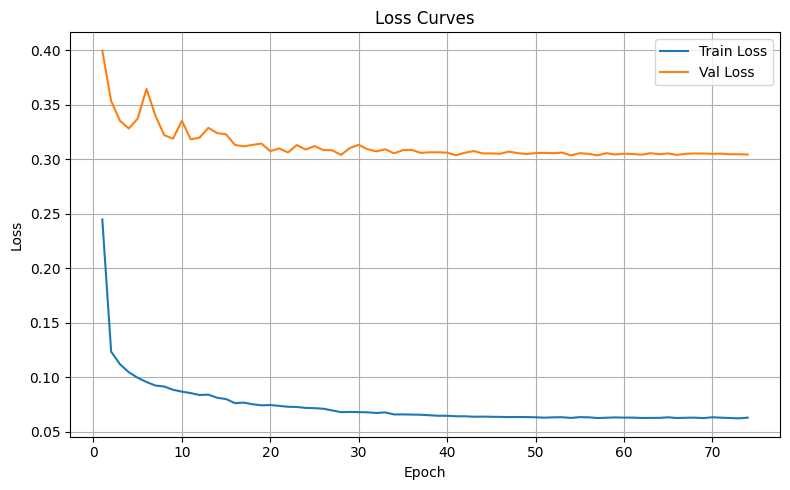

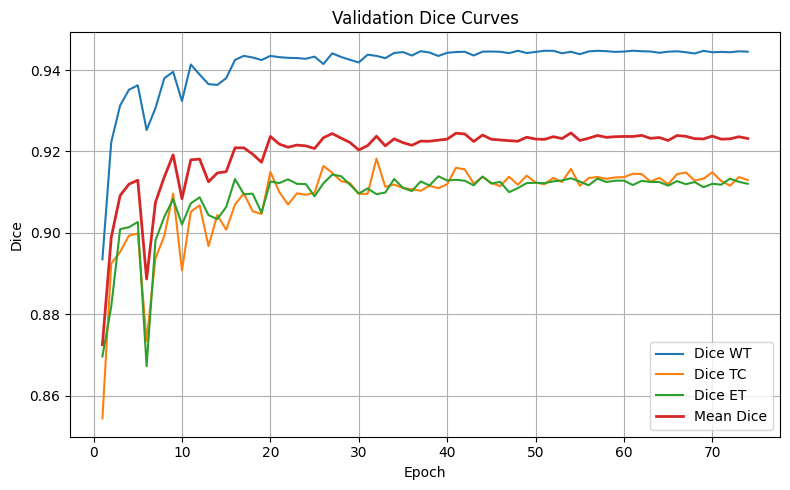

Best epoch log:
{'epoch': 54.0, 'learning_rate': 1.5625e-05, 'lr': 1.5625e-05, 'train_loss': 0.06283973667817094, 'train_dice_loss': 0.05533960609969305, 'train_bce_loss': 0.0075001305415661685, 'val_loss': 0.3036697477620285, 'val_dice_loss': 0.29037732612724476, 'val_bce_loss': 0.013292421491376678, 'val_dice': 0.9245484496973347, 'dice_wt': 0.944506847595486, 'dice_tc': 0.9157312222344881, 'dice_et': 0.9134072792620305, 'mean_dice': 0.9245484496973347}


In [ ]:
def load_logs(log_path):
    rows = []

    with open(log_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)

        for row in reader:
            rows.append({k: float(v) for k, v in row.items()})

    return rows

logs = load_logs(log_path)

epochs = [r["epoch"] for r in logs]

train_loss = [r["train_loss"] for r in logs]
val_loss = [r["val_loss"] for r in logs]

dice_wt = [r["dice_wt"] for r in logs]
dice_tc = [r["dice_tc"] for r in logs]
dice_et = [r["dice_et"] for r in logs]
mean_dice = [r["mean_dice"] for r in logs]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curve.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, dice_wt, label="Dice WT")
plt.plot(epochs, dice_tc, label="Dice TC")
plt.plot(epochs, dice_et, label="Dice ET")
plt.plot(epochs, mean_dice, label="Mean Dice", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Validation Dice Curves")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dice_curve.png", dpi=150)
plt.show()

best_idx = int(np.argmax(mean_dice))

print("Best epoch log:")
print(logs[best_idx])

## 16. Load Best Model and Visualize Final Predictions

Use this cell after training.

It loads `best_model.pth` and generates final validation prediction maps.

Loaded best model from epoch: 54
Best Mean Dice: 0.9245484496973347


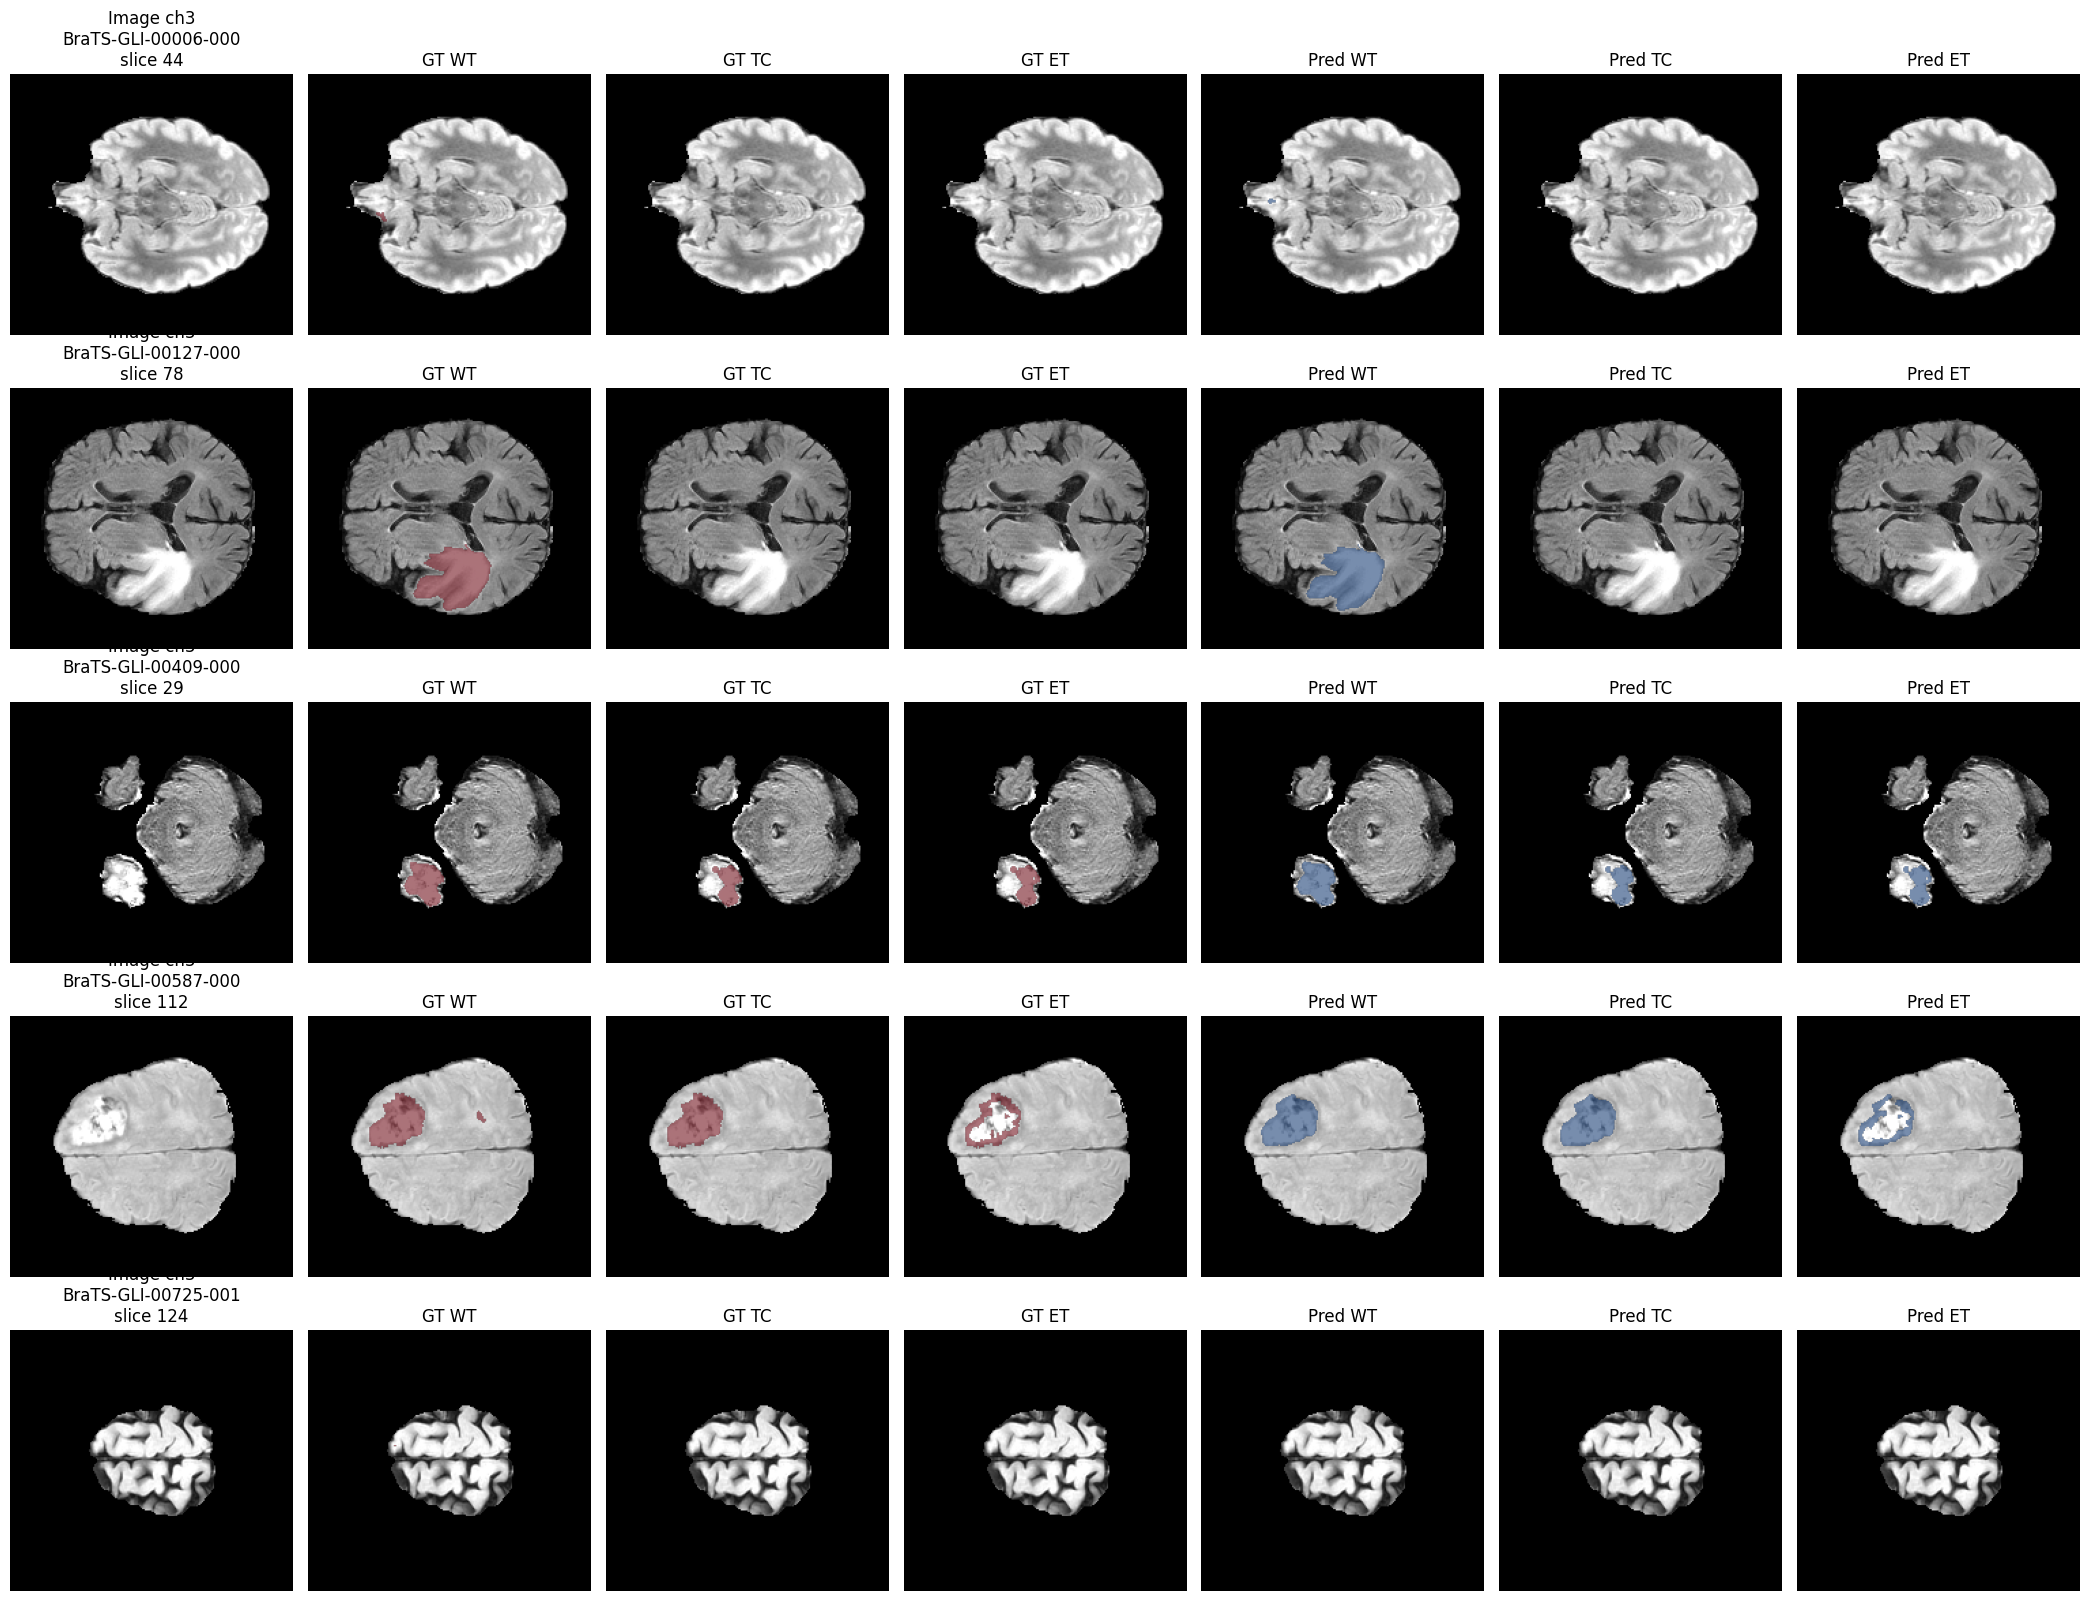

In [ ]:

best_checkpoint = torch.load(
    best_model_path,
    map_location=DEVICE,
)

model.load_state_dict(best_checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

print("Loaded best model from epoch:", best_checkpoint["epoch"])
print("Best Mean Dice:", best_checkpoint["best_mean_dice"])

visualize_predictions(
    model=model,
    dataset=val_dataset,
    device=DEVICE,
    save_path=OUTPUT_DIR / "prediction_best_model.png",
    num_samples=5,
    image_channel=3,
    threshold=THRESHOLD,
)

Loading best model
Best model path: outputs_task2_unet2d\best_unet.pth
Best model loaded successfully.

Searching all validation slices
Constraint: dice_wt != 1, dice_tc != 1, dice_et != 1
Total slices in dataset: 7882
Excluded slices: 2756
Valid candidate slices: 5126

Selected top 5 slices
Rank 1: case_id=BraTS-GLI-00479-001, slice_idx=92, WT=0.992373, TC=0.996898, ET=0.996891, Mean=0.995387
Rank 2: case_id=BraTS-GLI-00214-000, slice_idx=102, WT=0.992903, TC=0.996956, ET=0.994136, Mean=0.994665
Rank 3: case_id=BraTS-GLI-00214-000, slice_idx=103, WT=0.993781, TC=0.996902, ET=0.992104, Mean=0.994262
Rank 4: case_id=BraTS-GLI-00214-000, slice_idx=108, WT=0.989280, TC=0.996307, ET=0.995803, Mean=0.993797
Rank 5: case_id=BraTS-GLI-00479-001, slice_idx=91, WT=0.991685, TC=0.998158, ET=0.991237, Mean=0.993693



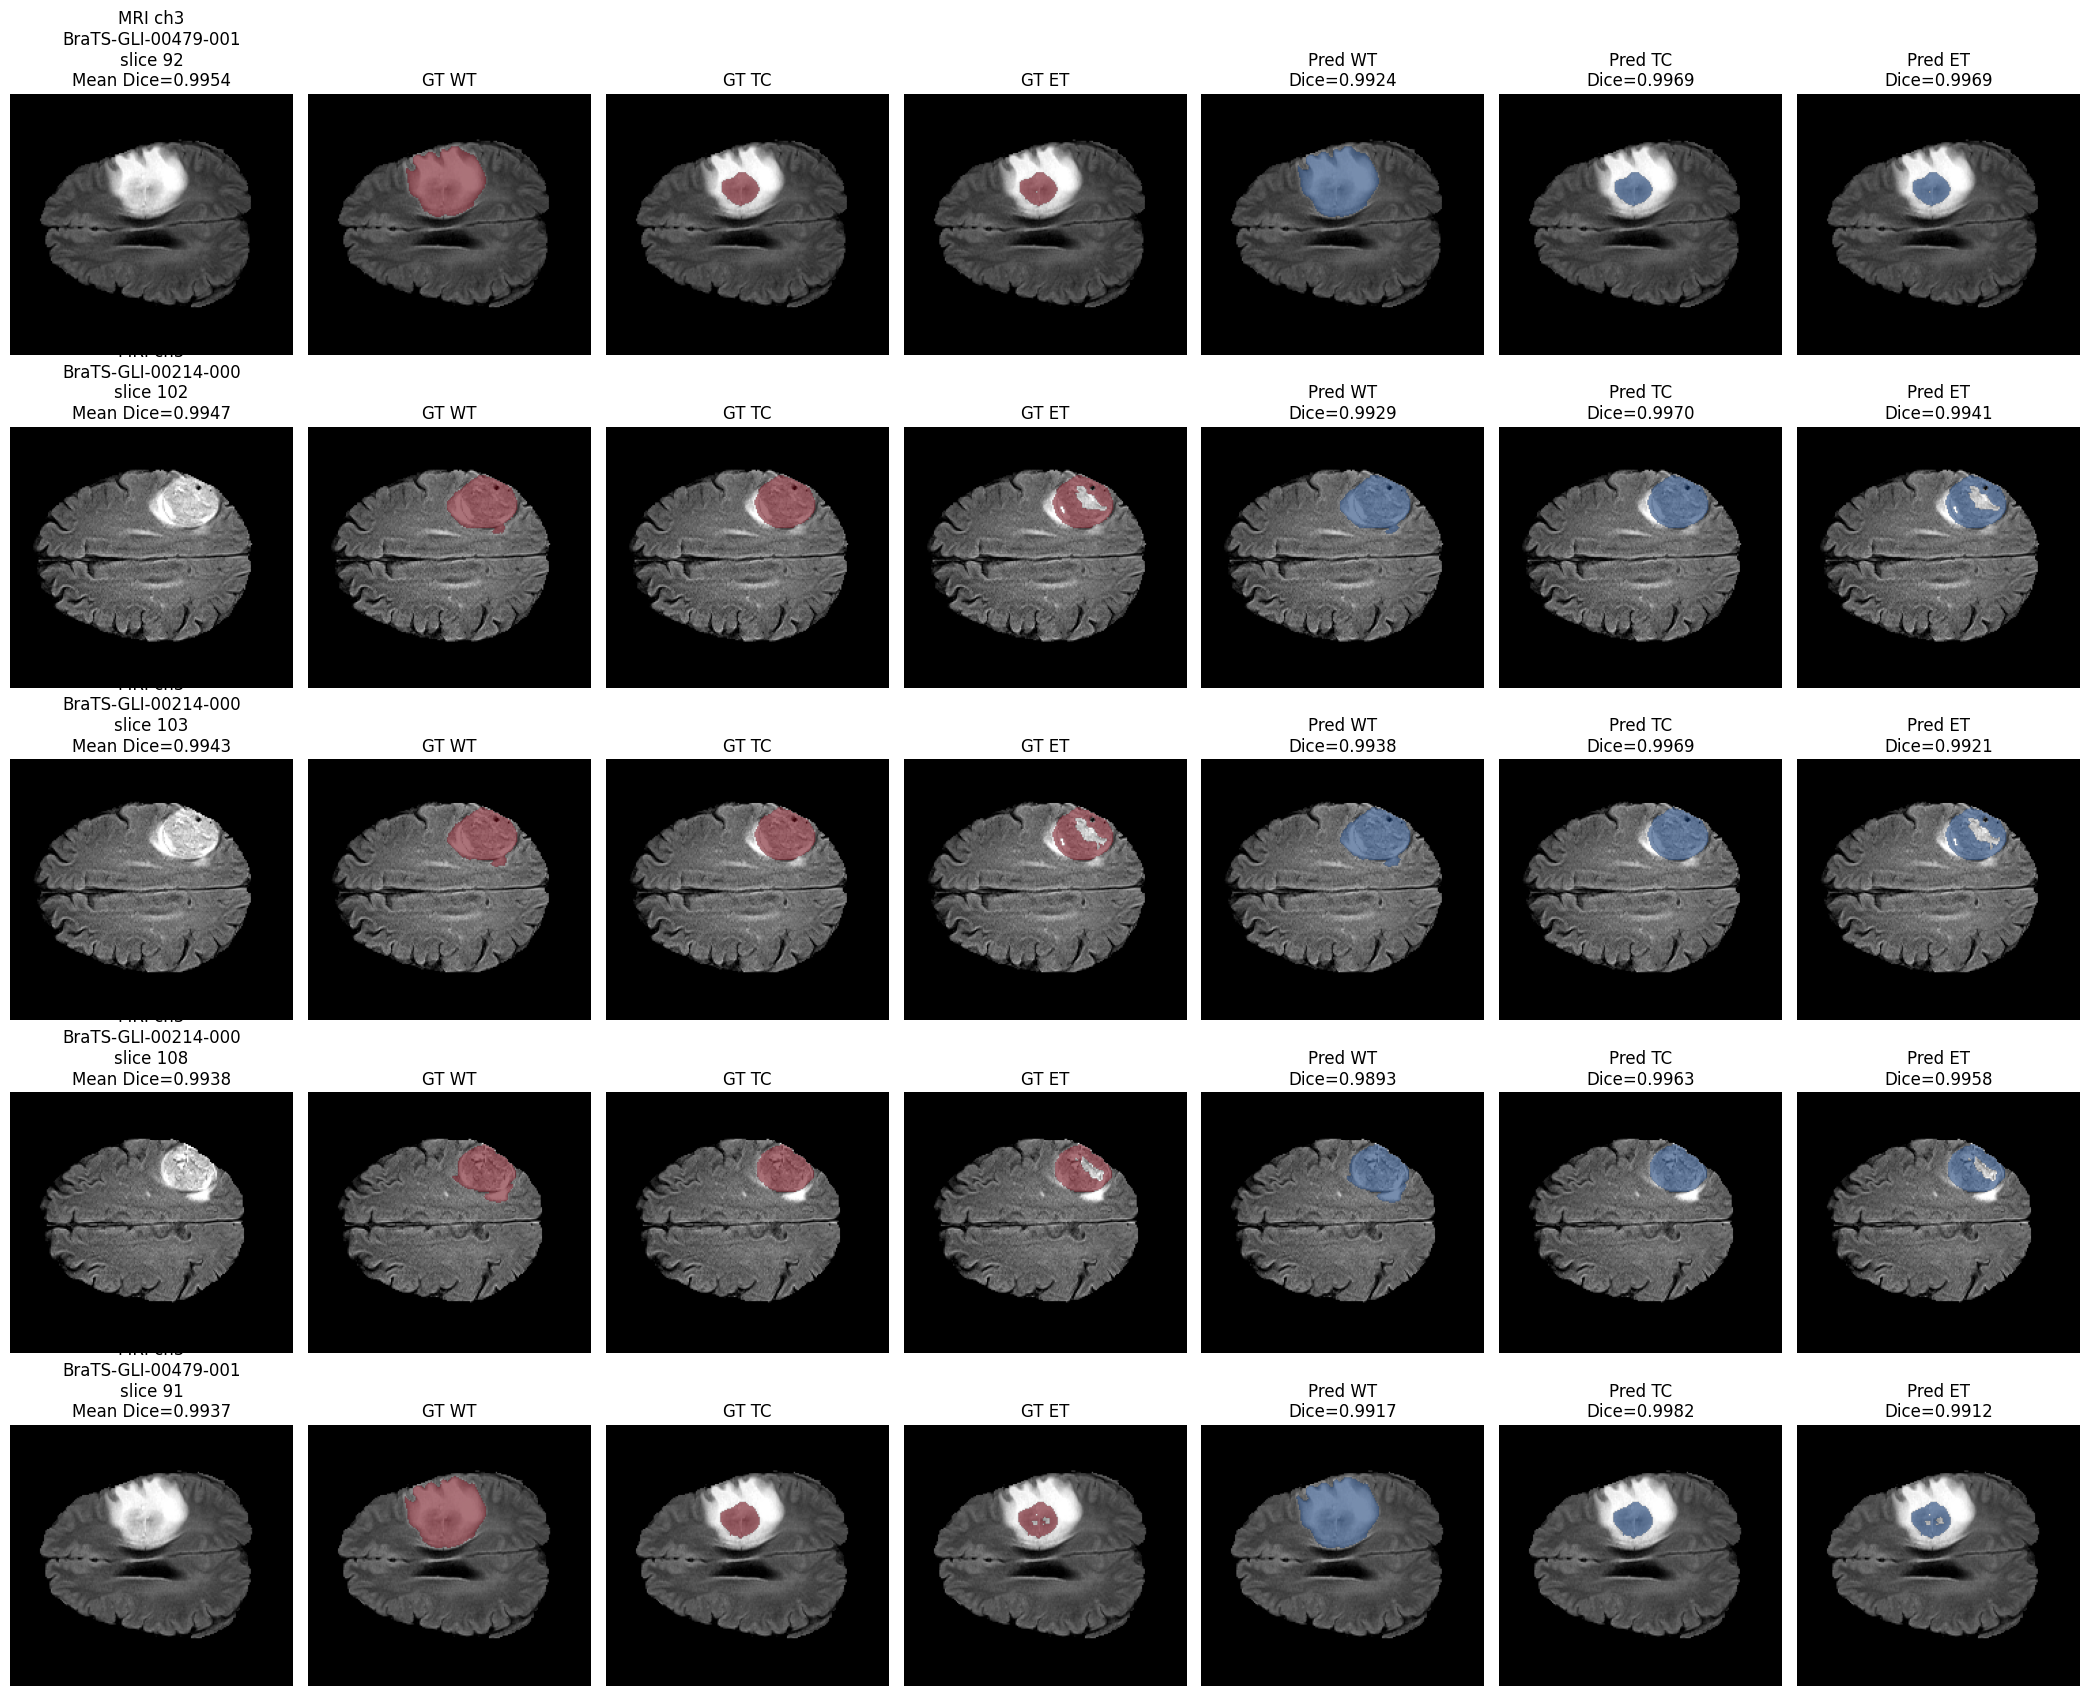

Saved visualization to: D:\Classes\AIformedical\LAB2\Lab2\outputs_task2_unet2d\best_model_top5_full_slices_dice_not_equal_1_overlay.png


In [18]:
# ============================================================
# Load Best Model and Visualize Final Predictions
# Full-slice search, select best 5 slices where:
# dice_wt != 1, dice_tc != 1, dice_et != 1
#
# Layout:
# MRI | GT WT | GT TC | GT ET | Pred WT | Pred TC | Pred ET
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

VIS_DATASET = val_dataset

TOP_K = 5
IMAGE_CHANNEL = 3

if "THRESHOLD" in globals():
    VIS_THRESHOLD = THRESHOLD
else:
    VIS_THRESHOLD = 0.5

DICE_ONE_EPS = 1e-7

SAVE_PATH = OUTPUT_DIR / "best_model_top5_full_slices_dice_not_equal_1_overlay.png"

if "best_model_path" in globals():
    BEST_MODEL_PATH = Path(best_model_path)
else:
    BEST_MODEL_PATH = OUTPUT_DIR / "best_model.pth"


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def to_python_value(x):
    if torch.is_tensor(x):
        if x.numel() == 1:
            return x.item()
        return x.detach().cpu().numpy().tolist()

    if isinstance(x, np.ndarray):
        if x.shape == ():
            return x.item()
        return x.tolist()

    return x


def estimate_background_value_from_corners(img):
    """
    Estimate MRI background / padding value from four corners.

    For your processed data, background is not necessarily 0.
    It is usually equal to a negative normalized value.
    """
    h, w = img.shape

    corner_values = np.array(
        [
            img[0, 0],
            img[0, w - 1],
            img[h - 1, 0],
            img[h - 1, w - 1],
        ],
        dtype=np.float32,
    )

    background_value = float(np.median(corner_values))

    return background_value


def normalize_mri_for_display_with_background(img, eps=1e-6):
    """
    Normalize MRI slice for visualization only.

    - Estimate background value from image corners.
    - Force background to black.
    - Normalize foreground using percentile clipping.
    """
    img = img.astype(np.float32)

    background_value = estimate_background_value_from_corners(img)

    foreground_mask = np.abs(img - background_value) > eps

    out = np.zeros_like(img, dtype=np.float32)

    if foreground_mask.sum() == 0:
        return out

    foreground_values = img[foreground_mask]

    vmin = np.percentile(foreground_values, 1)
    vmax = np.percentile(foreground_values, 99)

    if vmax <= vmin:
        return out

    out[foreground_mask] = (img[foreground_mask] - vmin) / (vmax - vmin)
    out = np.clip(out, 0.0, 1.0)

    return out


def compute_hard_dice_per_channel(pred, target, eps=1e-7):
    """
    pred:   numpy array, shape [3, H, W], binary 0/1
    target: numpy array, shape [3, H, W], binary 0/1

    Returns:
        dice_per_channel: numpy array, shape [3]
        mean_dice: float
    """
    dice_scores = []

    for c in range(target.shape[0]):
        pred_c = pred[c].astype(bool)
        target_c = target[c].astype(bool)

        pred_sum = pred_c.sum()
        target_sum = target_c.sum()

        if pred_sum + target_sum == 0:
            dice = 1.0
        else:
            intersection = np.logical_and(pred_c, target_c).sum()
            dice = (2.0 * intersection + eps) / (
                pred_sum + target_sum + eps
            )

        dice_scores.append(float(dice))

    dice_scores = np.array(dice_scores, dtype=np.float32)
    mean_dice = float(dice_scores.mean())

    return dice_scores, mean_dice


def get_sample_arrays(sample):
    image = sample["image"]
    label = sample["label"]

    if torch.is_tensor(image):
        image_np = image.detach().cpu().numpy()
    else:
        image_np = np.asarray(image)

    if torch.is_tensor(label):
        label_np = label.detach().cpu().numpy()
    else:
        label_np = np.asarray(label)

    case_id = to_python_value(sample["case_id"])
    slice_idx = int(to_python_value(sample["slice_idx"]))

    return image_np, label_np, case_id, slice_idx


# ------------------------------------------------------------
# Load best model
# ------------------------------------------------------------

print("=" * 80)
print("Loading best model")
print("=" * 80)
print("Best model path:", BEST_MODEL_PATH)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    model.load_state_dict(checkpoint["state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(DEVICE)
model.eval()

print("Best model loaded successfully.")
print()


# ------------------------------------------------------------
# Rank all validation slices by hard mean Dice
# Constraint:
# dice_wt < 1, dice_tc < 1, dice_et < 1
# ------------------------------------------------------------

@torch.no_grad()
def rank_best_slices_full_range_dice_not_equal_one(
    model,
    dataset,
    device,
    threshold=0.5,
    dice_one_eps=1e-7,
):
    model.eval()

    candidates = []
    excluded_equal_one = 0

    print("=" * 80)
    print("Searching all validation slices")
    print("Constraint: dice_wt != 1, dice_tc != 1, dice_et != 1")
    print("=" * 80)

    for idx in range(len(dataset)):
        sample = dataset[idx]

        image_tensor = sample["image"].unsqueeze(0).to(device)
        label_np = sample["label"].detach().cpu().numpy()

        logits = model(image_tensor)
        probs = torch.sigmoid(logits)[0].detach().cpu().numpy()
        pred_np = (probs > threshold).astype(np.uint8)

        dice_per_channel, mean_dice = compute_hard_dice_per_channel(
            pred=pred_np,
            target=label_np,
        )

        dice_wt = float(dice_per_channel[0])
        dice_tc = float(dice_per_channel[1])
        dice_et = float(dice_per_channel[2])

        # Strict condition:
        # all three label dice values must be different from 1.
        # Floating-safe version:
        valid = (
            dice_wt < 1.0 - dice_one_eps
            and dice_tc < 1.0 - dice_one_eps
            and dice_et < 1.0 - dice_one_eps
        )

        if not valid:
            excluded_equal_one += 1
            continue

        case_id = to_python_value(sample["case_id"])
        slice_idx = int(to_python_value(sample["slice_idx"]))

        candidates.append(
            {
                "dataset_idx": idx,
                "case_id": case_id,
                "slice_idx": slice_idx,
                "dice_wt": dice_wt,
                "dice_tc": dice_tc,
                "dice_et": dice_et,
                "mean_dice": float(mean_dice),
            }
        )

    if len(candidates) == 0:
        raise RuntimeError(
            "No valid candidate slices found. "
            "All slices were excluded because at least one of "
            "dice_wt, dice_tc, dice_et was equal or extremely close to 1."
        )

    candidates = sorted(
        candidates,
        key=lambda x: x["mean_dice"],
        reverse=True,
    )

    print(f"Total slices in dataset: {len(dataset)}")
    print(f"Excluded slices: {excluded_equal_one}")
    print(f"Valid candidate slices: {len(candidates)}")
    print()

    return candidates


ranked_candidates = rank_best_slices_full_range_dice_not_equal_one(
    model=model,
    dataset=VIS_DATASET,
    device=DEVICE,
    threshold=VIS_THRESHOLD,
    dice_one_eps=DICE_ONE_EPS,
)

top_candidates = ranked_candidates[:TOP_K]

print("=" * 80)
print(f"Selected top {len(top_candidates)} slices")
print("=" * 80)

for i, item in enumerate(top_candidates, start=1):
    print(
        f"Rank {i}: "
        f"case_id={item['case_id']}, "
        f"slice_idx={item['slice_idx']}, "
        f"WT={item['dice_wt']:.6f}, "
        f"TC={item['dice_tc']:.6f}, "
        f"ET={item['dice_et']:.6f}, "
        f"Mean={item['mean_dice']:.6f}"
    )

print()


# ------------------------------------------------------------
# Visualize selected top slices
# ------------------------------------------------------------

@torch.no_grad()
def visualize_top_slices_overlay(
    model,
    dataset,
    selected_items,
    device,
    save_path,
    image_channel=3,
    threshold=0.5,
):
    model.eval()

    num_samples = len(selected_items)

    fig, axes = plt.subplots(
        num_samples,
        7,
        figsize=(21, 3.4 * num_samples),
    )

    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    red_cmap = plt.cm.Reds.copy()
    red_cmap.set_bad(color=(0, 0, 0, 0))

    blue_cmap = plt.cm.Blues.copy()
    blue_cmap.set_bad(color=(0, 0, 0, 0))

    region_names = REGION_NAMES if "REGION_NAMES" in globals() else ["WT", "TC", "ET"]

    for row, item in enumerate(selected_items):
        idx = item["dataset_idx"]
        sample = dataset[idx]

        image_tensor = sample["image"].unsqueeze(0).to(device)

        image_np, label_np, case_id, slice_idx = get_sample_arrays(sample)

        logits = model(image_tensor)
        probs = torch.sigmoid(logits)[0].detach().cpu().numpy()
        pred_np = (probs > threshold).astype(np.uint8)

        bg = image_np[image_channel]
        bg_display = normalize_mri_for_display_with_background(bg)

        dice_wt = item["dice_wt"]
        dice_tc = item["dice_tc"]
        dice_et = item["dice_et"]
        mean_dice = item["mean_dice"]

        # ----------------------------------------------------
        # Column 0: MRI image
        # ----------------------------------------------------
        axes[row, 0].imshow(
            bg_display,
            cmap="gray",
            vmin=0,
            vmax=1,
        )

        axes[row, 0].set_title(
            f"MRI ch{image_channel}\n"
            f"{case_id}\n"
            f"slice {slice_idx}\n"
            f"Mean Dice={mean_dice:.4f}"
        )
        axes[row, 0].axis("off")

        # ----------------------------------------------------
        # Columns 1-3: GT WT / TC / ET overlay
        # ----------------------------------------------------
        for c, name in enumerate(region_names):
            axes[row, 1 + c].imshow(
                bg_display,
                cmap="gray",
                vmin=0,
                vmax=1,
            )

            gt_mask = np.ma.masked_where(
                label_np[c] <= 0.5,
                label_np[c],
            )

            axes[row, 1 + c].imshow(
                gt_mask,
                cmap=red_cmap,
                alpha=0.55,
                vmin=0,
                vmax=1,
            )

            axes[row, 1 + c].set_title(f"GT {name}")
            axes[row, 1 + c].axis("off")

        # ----------------------------------------------------
        # Columns 4-6: Pred WT / TC / ET overlay
        # ----------------------------------------------------
        dice_values = [dice_wt, dice_tc, dice_et]

        for c, name in enumerate(region_names):
            axes[row, 4 + c].imshow(
                bg_display,
                cmap="gray",
                vmin=0,
                vmax=1,
            )

            pred_mask = np.ma.masked_where(
                pred_np[c] <= 0.5,
                pred_np[c],
            )

            axes[row, 4 + c].imshow(
                pred_mask,
                cmap=blue_cmap,
                alpha=0.55,
                vmin=0,
                vmax=1,
            )

            axes[row, 4 + c].set_title(
                f"Pred {name}\nDice={dice_values[c]:.4f}"
            )
            axes[row, 4 + c].axis("off")

    plt.tight_layout()

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print("Saved visualization to:", save_path.resolve())


visualize_top_slices_overlay(
    model=model,
    dataset=VIS_DATASET,
    selected_items=top_candidates,
    device=DEVICE,
    save_path=SAVE_PATH,
    image_channel=IMAGE_CHANNEL,
    threshold=VIS_THRESHOLD,
)

Loaded best model for test evaluation: outputs_task2_unet2d\best_unet.pth
Checkpoint epoch: 54
Best validation mean Dice: 0.9245484496973347


Test Dice: 0.8919 ± 0.1664
Test HD95: 3.1286 ± 5.1717
Per-case/per-slice metrics: outputs_task2_unet2d\test_metrics_per_case.csv
Summary metrics: outputs_task2_unet2d\test_metrics_summary.csv
Worst-5 error analysis skipped.
Test metrics across cases
  Mean Dice  : 0.8886  ±0.0613  [0.6726, 0.9686]
  Mean HD95  : 3.06  ±1.99  [0.68, 11.08]

Per-region Dice:
  WT: 0.8525 ± 0.1055
  TC: 0.9151 ± 0.0525
  ET: 0.8981 ± 0.0568

Case-level metrics saved to: outputs_task2_unet2d\test_metrics_per_case_aggregated.csv


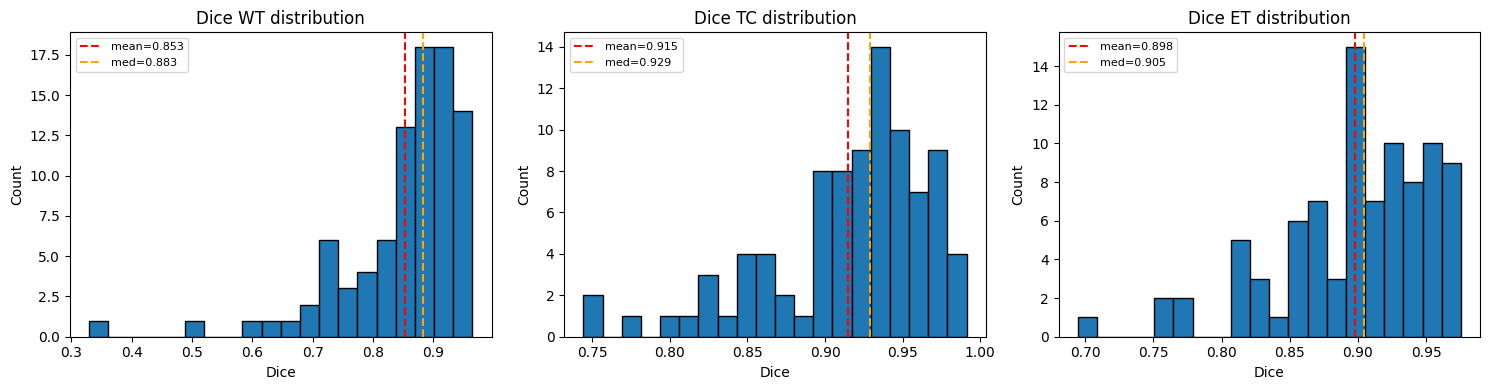

In [19]:
# ============================================================
# Test evaluation: Dice + HD95 only
# ============================================================


if "best_model_path" not in globals():
    best_model_path = OUTPUT_DIR / "best_unet.pth"

metric_rows, summary_rows = run_test_evaluation(
    model=model,
    test_loader=test_loader,
    test_dataset=test_dataset,
    device=DEVICE,
    output_dir=OUTPUT_DIR,
    best_model_path=best_model_path,
    region_names=REGION_NAMES,
    threshold=THRESHOLD,
    save_worst5=False,
)


def finite_values(values):
    values = np.asarray(values, dtype=np.float64)
    return values[~np.isnan(values)]


def summarize_values(values):
    values = finite_values(values)
    if values.size == 0:
        return np.nan, np.nan, np.nan, np.nan
    return (
        float(np.mean(values)),
        float(np.std(values)),
        float(np.min(values)),
        float(np.max(values)),
    )


def aggregate_metrics_by_case(rows):
    case_to_rows = defaultdict(list)
    for row in rows:
        case_to_rows[row["case_id"]].append(row)

    metric_keys = ["dice", "hd95"] + [f"dice_{name.lower()}" for name in REGION_NAMES]
    metric_keys += [f"hd95_{name.lower()}" for name in REGION_NAMES]

    case_results = []
    for case_id, case_rows in sorted(case_to_rows.items()):
        case_result = {
            "case_id": case_id,
            "num_slices": len(case_rows),
            "slice_start": min(int(r["slice_idx"]) for r in case_rows),
            "slice_end": max(int(r["slice_idx"]) for r in case_rows),
        }

        for key in metric_keys:
            vals = [float(r[key]) for r in case_rows if key in r and r[key] != ""]
            vals = finite_values(vals)
            case_result[key] = float(np.mean(vals)) if vals.size > 0 else np.nan

        case_results.append(case_result)

    return case_results


def save_case_results_csv(case_results, save_path):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = []
    for row in case_results:
        for key in row.keys():
            if key not in fieldnames:
                fieldnames.append(key)

    with open(save_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(case_results)


case_results = aggregate_metrics_by_case(metric_rows)
case_results_path = OUTPUT_DIR / "test_metrics_per_case_aggregated.csv"
save_case_results_csv(case_results, case_results_path)

mean_dice, std_dice, min_dice, max_dice = summarize_values(
    [r["dice"] for r in case_results]
)
mean_hd95, std_hd95, min_hd95, max_hd95 = summarize_values(
    [r["hd95"] for r in case_results]
)

print("Test metrics across cases")
print(
    f"  Mean Dice  : {mean_dice:.4f}  ±{std_dice:.4f}  [{min_dice:.4f}, {max_dice:.4f}]"
)
print(
    f"  Mean HD95  : {mean_hd95:.2f}  ±{std_hd95:.2f}  [{min_hd95:.2f}, {max_hd95:.2f}]"
)
print()
print("Per-region Dice:")
for name in REGION_NAMES:
    key = f"dice_{name.lower()}"
    region_mean, region_std, _, _ = summarize_values([r[key] for r in case_results])
    print(f"  {name}: {region_mean:.4f} ± {region_std:.4f}")

print()
print("Case-level metrics saved to:", case_results_path)

# Distribution of Dice across all test cases.
fig, axes = plt.subplots(1, len(REGION_NAMES), figsize=(5 * len(REGION_NAMES), 4))
if len(REGION_NAMES) == 1:
    axes = [axes]

for i, name in enumerate(REGION_NAMES):
    key = f"dice_{name.lower()}"
    vals = finite_values([r[key] for r in case_results])

    axes[i].hist(vals, bins=20, edgecolor="black")
    axes[i].axvline(
        np.mean(vals),
        color="red",
        linestyle="--",
        label=f"mean={np.mean(vals):.3f}",
    )
    axes[i].axvline(
        np.median(vals),
        color="orange",
        linestyle="--",
        label=f"med={np.median(vals):.3f}",
    )
    axes[i].set_title(f"Dice {name} distribution")
    axes[i].set_xlabel("Dice")
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dice_distribution.png", dpi=150)
plt.show()

## 17. Notes for Report

You can describe this baseline as follows:

- Dataset: 595 cases, 38,976 2D slices
- Input: four-channel MRI image, shape `(4, 192, 208)`
- Label: three-channel binary mask, shape `(3, 192, 208)`
- Regions: WT, TC, ET
- Model: 2D U-Net
- Loss: Dice Loss + BCEWithLogitsLoss
- Optimizer: AdamW
- Scheduler: ReduceLROnPlateau
- Split: patient-level train/validation split
- Metrics: Dice WT, Dice TC, Dice ET, Mean Dice

Because WT, TC and ET are nested regions rather than mutually exclusive classes, this experiment formulates the task as multi-label segmentation and applies sigmoid activation to each output channel independently.
